# Pregunta de negoci:
## Analisis de Màrqueting i Estratègia Comercial: 
- Analista de Màrqueting i Estratègia Comercial: Quins ciutat i barris presenten un potencial
d'optimització més gran considerant les ressenyes, la puntuació de la zona i la disponibilitat
mínima/màxima de nits?

### Details
* identificar el preu mitjà per tipus d’allotjament a cada ciutat 
* detectar oportunitats comercials 
* definir estratègies de pricing 

### Tools

#### Libraries

In [1]:
#_____________________________________________________
from dotenv import load_dotenv
load_dotenv()   # reads .env file
#_____________________________________________________
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import pearsonr, spearmanr, chi2_contingency, boxcox, kruskal

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from IPython.display import Image as IPyImage
try:
    from IPython.display import display
except ImportError:
    display = print

# --------------------------------------------------
# Paths
# Notebook expected in ~/Scripts/
# Results required in ~/Results/
# --------------------------------------------------
RESULTS_DIR = Path("~/Results").expanduser()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
# --------------------------------------------------


#### Clasificación de anuncios
|city|minimal|maximal|type|ref|
|----|-------|-------|----|--------------------|
|Barcelona|1|31|Alojamiento de uso turístico|[1]|
|Barcelona|32|Max|Otro uso|[1]|
|Girona|1|31|Alojamiento de uso turístico|[1]|
|Girona|32|Max|Otro uso|[1]|
|Madrid|1|31|Alojamiento de uso turístico|[2]|
|Madrid|32|Max|Otro uso|[2]|
|Sevilla|1|60|Alojamiento de uso turístico|[3]|
|Sevilla|61|Max|Otro uso|[3]|
|Malaga|1|60|Alojamiento de uso turístico|[3]|
|Malaga|61|Max|Otro uso|[3]|
|Mallorca|1|60|Alojamiento de uso turístico|[4]|
|Mallorca|61|Max|Otro uso|[4]|
|Menorca|1|31|Alojamiento de uso turístico|[5]|
|Menorca|32|Max|Otro uso|[5]|

___
Referencias:

[1]https://portaljuridic.gencat.cat/eli/es-ct/d/2012/11/20/159
Títol II    Article 66  Definicions i àmbit d'aplicació
3. Als efectes d’aquest Decret es considera estada de temporada tota ocupació de l’habitatge per un període de temps continu igual o inferior a 31 dies.

[2]https://thekeyhost.es/blog/cuanto-tiempo-se-puede-alquilar-un-piso-turistico/
- Alquiler turístico o vacacional: estancias de corta duración (normalmente menos de 31 días) ofrecidas de forma habitual y con fines turísticos.

[3]https://www.juntadeandalucia.es/organismos/turismoyandaluciaexterior/areas/registro-turismo/establecimientos-servicios/paginas/faq-viviendas-turismo.html
- Las viviendas arrendadas por tiempo superior a dos meses computados de forma continuada a un mismo arrendatario.

[4]https://www.vacaciones-espana.es/rentalbuzz/leyes-y-licencias-de-estancias-turisticas-vacacionales-en-mallorca
- Este tipo de propiedades se pueden alquilar por un período máximo de 60 días por año.

[5]https://abogadomenorca.com/alquileres-menorca/
- El Alquiler Turístico en Menorca se regula por la normativa del Consell Insular de Menorca. Se trata de alquileres por periodos de corta duración (por días o semanas), sin que una estancia pueda ser superior a un mes.

#### Functions

In [ ]:
# Chi-square estimation

def chi_square_with_target(df, target_col):
    
    """
    Perform chi-square test of independence between a target categorical column
    and all other columns in the DataFrame.
    """
    results = []

    # Ensure target column is categorical or object type
    if df[target_col].dtype not in ["object", "category", "int"]:
        raise ValueError("Target column must be categorical or integer.")

    for col in df.columns:
        if col == target_col:
            continue

        # Skip non-categorical columns (continuous numeric data is not suitable for chi-square)
        if df[col].dtype not in ["object", "category", "int"]:
            continue

        # Drop rows with NaN in either column
        valid_mask = df[[target_col, col]].notna().all(axis=1)
        sub_df = df.loc[valid_mask, [target_col, col]]

        # Create contingency table
        contingency_table = pd.crosstab(sub_df[target_col], sub_df[col])

        # Perform chi-square test
        chi2, p, dof, expected = chi2_contingency(contingency_table)

        results.append(
            {
                "target_column": target_col,
                "compared_column": col,
                "chi2_statistic": round(chi2, 2),
                "p_value": p,
                "degrees_of_freedom": dof,
            }
        )

    return pd.DataFrame(results)

In [3]:
# Mann Whitney test estimation


def mann_whitney_with_target(df, target_col):
    """
    Perform Mann-Whitney U test between a target binary categorical column
    and all other numeric columns in the DataFrame.
    """
    results = []

    # Ensure target column is categorical, object, or binary integer
    if df[target_col].dtype not in ["object", "category", "int", "int64", "float64"]:
        raise ValueError("Target column must be categorical or binary numeric.")

    # Check target has exactly two groups
    target_values = df[target_col].dropna().unique()
    if len(target_values) != 2:
        raise ValueError("Target column must have exactly two groups for Mann-Whitney U test.")

    group_1, group_2 = target_values

    for col in df.columns:
        if col == target_col:
            continue

        # Only numeric columns are suitable for Mann-Whitney U
        if df[col].dtype not in ["int", "int64", "float", "float64"]:
            continue

        # Drop rows with NaN in either column
        valid_mask = df[[target_col, col]].notna().all(axis=1)
        sub_df = df.loc[valid_mask, [target_col, col]]

        # Split values by target group
        sample_1 = sub_df.loc[sub_df[target_col] == group_1, col]
        sample_2 = sub_df.loc[sub_df[target_col] == group_2, col]

        # Skip if either group is empty
        if len(sample_1) == 0 or len(sample_2) == 0:
            continue

        # Perform Mann-Whitney U test
        u_stat, p_value = mannwhitneyu(sample_1, sample_2, alternative="two-sided")

        results.append(
            {
                "target_column": target_col,
                "compared_column": col,
                "group_1": group_1,
                "group_2": group_2,
                "u_statistic": round(u_stat, 2),
                "p_value": p_value,
                "group_1_median": round(sample_1.median(), 2),
                "group_2_median": round(sample_2.median(), 2),
            }
        )

    return pd.DataFrame(results)

In [4]:
# Statistical reporting Block
sns.set_theme(style="whitegrid")

# --------------------------------------------------
# Paths
# Notebook expected in ~/Scripts/
# Results required in ~/Results/
# --------------------------------------------------
SCRIPTS_DIR = Path("~/Scripts").expanduser()
RESULTS_DIR = Path("~/Results").expanduser()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def get_notebook_dir():
    """
    Devuelve el directorio que contiene el cuaderno de Jupyter o el script de Python actual.

    En las sesiones de Jupyter de VS Code, utiliza la ruta del cuaderno; en caso contrario, 
    recurre al directorio del script o al directorio de trabajo actual.

    Devuelve
    -------
    Path
        Ruta del directorio como un objeto ``pathlib.Path``.
    """
    try:
        # Specific variable available in VS Code Jupyter environment
        return Path(__vsc_ipynb_file__).parent
    except NameError:
        # Fallback for standard .py scripts or other environments
        return Path(__file__).parent if "__file__" in globals() else Path.cwd()

def classify_series_type(s: pd.Series, ordinal_threshold: int = 10) -> str:
    """
    Clasifica el tipo de una serie pandas (numeric, ordinal, categorical, datetime)
    para seleccionar la prueba de correlación adecuada.

    Tipos devueltos:
        - 'numeric': numérico continuo.
        - 'ordinal': entero-like o numérico de baja cardinalidad (≤ 'threshold').
        - 'categorical': objeto, categoría o booleano.
        - 'datetime': tipo fecha/hora.

    Parámetros
    ----------
    s : pd.Series
        Serie a clasificar.
    ordinal_threshold : int, default=10
        Umbral de cardinalidad máxima para considerar una serie numérica como ordinal.

    Retorna
    -------
    str
        Tipo clasificado: 'numeric', 'ordinal', 'categorical' o 'datetime'.
    """
    if pd.api.types.is_datetime64_any_dtype(s):
        return "datetime"

    if pd.api.types.is_bool_dtype(s):
        return "categorical"

    if pd.api.types.is_numeric_dtype(s):
        non_null = s.dropna()
        nunique = non_null.nunique()
        if pd.api.types.is_integer_dtype(s) and nunique <= ordinal_threshold:
            return "ordinal"
        return "numeric"

    return "categorical"


def skew_interpretation(skew_value: float) -> str:
    """
    Interpreta el grado de asimetría de una distribución según su valor de skewness.

    Parámetros
    ----------
    skew_value : float
        Valor de coeficiente de asimetría (skewness).

    Retorna
    -------
    str
        Descripción del grado de asimetría:
        - "Approximately symmetric." si |skew| < 0.5
        - "Moderately skewed." si 0.5 ≤ |skew| < 1.0
        - "Highly skewed." si |skew| ≥ 1.0
    """
    a = abs(skew_value)
    if a < 0.5:
        return "Approximately symmetric."
    elif a < 1.0:
        return "Moderately skewed."
    else:
        return "Highly skewed."


def normality_improvement_text(original_skew: float, transformed_skew: float) -> str:
    """
    Devuelve una descripción breve del cambio en la asimetría tras una transformación.

    Parámetros
    ----------
    original_skew : float
        Coeficiente de asimetría original.
    transformed_skew : float
        Coeficiente de asimetría tras la transformación.

    Retorna
    -------
    str
        Mensaje que indica si:
        - la normalidad mejoró ("Improved strongly; distribution is closer to symmetric." 
        o "Improved strongly; distribution is closer to symmetric."),
        - cambió poco ("Little change in skewness.") o 
        - empeoró ("Did not improve normality; skewness increased.").
    """
    orig_abs = abs(original_skew)
    trans_abs = abs(transformed_skew)

    if np.isnan(trans_abs):
        return "Transformation not available."

    if trans_abs < orig_abs - 0.1:
        if trans_abs < 0.5:
            return "Improved strongly; distribution is closer to symmetric."
        return "Improved; skewness decreased."
    elif abs(trans_abs - orig_abs) <= 0.1:
        return "Little change in skewness."
    else:
        return "Did not improve normality; skewness increased."


def prepare_numeric_series(df: pd.DataFrame, target_col: str) -> pd.Series:
    """
    Convierte una columna del DataFrame en una Serie numérica limpia.

    Convierte la columna especificada a numérico, elimina valores no válidos (NaN)
    y asegura el tipo float. Lanza ValueError si no quedan valores numéricos usable.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame con los datos.
    target_col : str
        Nombre de la columna a convertir.

    Retorna
    -------
    pd.Series
        Serie numérica (float) sin valores nulos.

    Lanza
    -----
    ValueError
        Si la columna no contiene valores numéricos utilizables tras la conversión.
    """
    s = pd.to_numeric(df[target_col], errors="coerce")
    s = s.dropna().astype(float)
    if s.empty:
        raise ValueError(f"Column '{target_col}' has no usable numeric values after coercion.")
    return s


def summarize_distribution(s: pd.Series) -> dict:
    """
    Calcula un resumen estadístico de la distribución de una serie numérica.

    Parámetros
    ----------
    s : pd.Series
        Serie de Pandas con valores numéricos.

    Retorna
    -------
    dict
        Diccionario con las siguientes métricas:
        - n: número de observaciones.
        - mean: media aritmética.
        - median: mediana.
        - std: desviación estándar (muestra, ddof=1).
        - se: error estándar de la media.
        - ci95_low, ci95_high: límites del intervalo de confianza al 95% de la media.
        - q1, q3: cuartiles 1 y 3.
        - iqr: rango intercuartílico (Q3 - Q1).
        - lower_fence, upper_fence: cercas inferiores y superiores para detectar valores atípicos (método 1.5×IQR).
        - outlier_count: número de valores atípicos detectados.
        - skewness: coeficiente de asimetría.
        - skewness_interpretación: interpretación cualitativa de la asimetría (negativa, simétrica o positiva).
        - outliers: serie con los valores atípicos detectados.
    """
    n = len(s)
    mean_val = s.mean()
    median_val = s.median()
    std_val = s.std(ddof=1)
    se = std_val / np.sqrt(n) if n > 1 else np.nan
    ci95 = stats.t.ppf(0.975, df=n-1) * se if n > 1 else np.nan

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    skew_val = s.skew()

    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    outliers = s[(s < lower_fence) | (s > upper_fence)]

    return {
        "n": int(n),
        "mean": float(mean_val),
        "median": float(median_val),
        "std": float(std_val),
        "se": float(se) if pd.notna(se) else np.nan,
        "ci95_low": float(mean_val - ci95) if pd.notna(ci95) else np.nan,
        "ci95_high": float(mean_val + ci95) if pd.notna(ci95) else np.nan,
        "q1": float(q1),
        "q3": float(q3),
        "iqr": float(iqr),
        "lower_fence": float(lower_fence),
        "upper_fence": float(upper_fence),
        "outlier_count": int(len(outliers)),
        "skewness": float(skew_val),
        "skewness_interpretation": skew_interpretation(skew_val),
        "outliers": outliers.copy()
    }


def create_value_counts_table(series: pd.Series, column_name: str) -> pd.DataFrame:
    """
    Crea una tabla con recuentos y frecuencias de valores de una serie.

    Parámetros
    ----------
    series : pd.Series
    Serie de pandas a analizar.
    column_name : str
    Nombre del columna para incluir en la tabla.

    Retorna
    -------
    pd.DataFrame
    Tabla con columnas: 'column', 'value', 'count', 'frequency_non_null'.
    Los atributos del DataFrame incluyen 'number_non_null' y 'number_unique'.
    """
    non_null = series.dropna()
    counts = non_null.value_counts(dropna=False, sort=False)

    try:
        counts = counts.sort_index()
    except Exception:
        counts = counts.sort_index(key=lambda idx: idx.astype(str))

    freq = counts / non_null.shape[0] if non_null.shape[0] > 0 else np.nan

    tbl = pd.DataFrame({
        "column": column_name,
        "value": counts.index.astype(str),
        "count": counts.values,
        "frequency_non_null": np.round(freq.values, 6)
    })

    tbl.attrs["number_non_null"] = int(non_null.shape[0])
    tbl.attrs["number_unique"] = int(non_null.nunique(dropna=True))
    return tbl


def create_transformation_skewness_table(s: pd.Series) -> pd.DataFrame:
    """
    Crea una tabla de comparación de transformaciones para reducir la asimetría (skewness) de una serie numérica.

    Evalúa la asimetría original y tras aplicar transformaciones logarítmica, raíz cuadrada y Box-Cox,
    registrando el nuevo coeficiente de asimetría, su interpretación y la mejora respecto a la normalidad.

    Parámetros

    s : pd.Series
    Serie de datos numéricos a analizar.

    Devuelve

    pd.DataFrame
    Tabla con columnas:
    - method: nombre del método (Original, Log, Raíz Cuadrada, Box-Cox).
    - skewness: coeficiente de asimetría resultante.
    - interpretation: interpretación cualitativa de la asimetría.
    - normality_improvement: descripción del cambio en la normalidad.
    """
    rows = []
    original_skew = s.skew()

    rows.append({
        "method": "Original",
        "skewness": original_skew,
        "interpretation": skew_interpretation(original_skew),
        "normality_improvement": "Baseline."
    })

    # Log transformation
    if (s > 0).all():
        log_s = np.log(s)
        log_skew = pd.Series(log_s).skew()
    else:
        shift = 1 - s.min() if s.min() <= 0 else 0
        log_s = np.log(s + shift)
        log_skew = pd.Series(log_s).skew()

    rows.append({
        "method": "Log Transformation",
        "skewness": log_skew,
        "interpretation": skew_interpretation(log_skew),
        "normality_improvement": normality_improvement_text(original_skew, log_skew)
    })

    # Square root transformation
    if (s >= 0).all():
        sqrt_s = np.sqrt(s)
        sqrt_skew = pd.Series(sqrt_s).skew()
    else:
        shift = -s.min()
        sqrt_s = np.sqrt(s + shift)
        sqrt_skew = pd.Series(sqrt_s).skew()

    rows.append({
        "method": "Square Root Transformation",
        "skewness": sqrt_skew,
        "interpretation": skew_interpretation(sqrt_skew),
        "normality_improvement": normality_improvement_text(original_skew, sqrt_skew)
    })

    # Box-Cox transformation
    try:
        if (s > 0).all():
            bc_input = s.copy()
        else:
            shift = 1 - s.min()
            bc_input = s + shift

        bc_values, bc_lambda = boxcox(bc_input)
        bc_skew = pd.Series(bc_values).skew()
        bc_note = f"Improved using lambda={bc_lambda:.4f}." if abs(bc_skew) < abs(original_skew) else f"Lambda={bc_lambda:.4f} did not improve enough."
    except Exception:
        bc_skew = np.nan
        bc_note = "Box-Cox could not be computed."

    rows.append({
        "method": "Box-Cox Transformation",
        "skewness": bc_skew,
        "interpretation": skew_interpretation(bc_skew) if pd.notna(bc_skew) else "Not available.",
        "normality_improvement": normality_improvement_text(original_skew, bc_skew) + f" {bc_note}"
    })

    return pd.DataFrame(rows)


def correlation_table(
    df: pd.DataFrame,
    target_col: str,
    ordinal_threshold: int = 10,
    max_categories: int = 50,
    alpha: float = 0.05
) -> pd.DataFrame:
    """
    Genera una tabla de asociación estadística entre una variable objetivo y el resto de columnas del DataFrame.

    Selecciona automáticamente la prueba según los tipos de variable (numérica, ordinal o categórica):
    Pearson para numérico-numérico, Spearman para ordinal-numérico/ordinal-ordinal, y Chi-cuadrado para
    comparaciones con variables categóricas (binando por cuantiles si es necesario).

    Parámetros
    ----------
    df : pd.DataFrame
    DataFrame con las variables a analizar.
    target_col : str
    Nombre de la columna objetivo (target).
    ordinal_threshold : int, default=10
    Umbral de categorías únicas para considerar una variable como ordinal en lugar de categórica.
    max_categories : int, default=50
    Límite máximo de categorías permitidas para calcular la tabla de contingencia (Chi-cuadrado).
    alpha : float, default=0.05
    Nivel de significancia estadística para interpretar el p-valor.

    Retorna
    -------
    pd.DataFrame
    Tabla con columns: target_column, target_type, other_column, other_type, test,
    statistic, p_value, significance, significance_interpretation, note.

    """
    target_raw = df[target_col]
    target_type = classify_series_type(target_raw, ordinal_threshold=ordinal_threshold)

    results = []

    for col in df.columns:
        if col == target_col:
            continue

        other = df[col]
        other_type = classify_series_type(other, ordinal_threshold=ordinal_threshold)

        test_name = None
        stat = np.nan
        pval = np.nan
        note = ""

        # Numeric target
        if target_type == "numeric":
            target_num = pd.to_numeric(target_raw, errors="coerce")

            if other_type == "numeric":
                other_num = pd.to_numeric(other, errors="coerce")
                tmp = pd.DataFrame({"x": target_num, "y": other_num}).dropna()
                if len(tmp) >= 3:
                    stat, pval = pearsonr(tmp["x"], tmp["y"])
                    test_name = "Pearson"
                else:
                    note = "Not enough paired non-null values."

            elif other_type == "ordinal":
                other_num = pd.to_numeric(other, errors="coerce")
                tmp = pd.DataFrame({"x": target_num, "y": other_num}).dropna()
                if len(tmp) >= 3:
                    stat, pval = spearmanr(tmp["x"], tmp["y"])
                    test_name = "Spearman"
                else:
                    note = "Not enough paired non-null values."

            elif other_type == "categorical":
                tmp = pd.DataFrame({"target": target_num, "group": other}).dropna()
                if tmp["group"].nunique() > 1:
                    try:
                        tmp["target_bin"] = pd.qcut(
                            tmp["target"],
                            q=min(5, tmp["target"].nunique()),
                            duplicates="drop"
                        )
                        if tmp["group"].nunique() <= max_categories and tmp["target_bin"].nunique() > 1:
                            ct = pd.crosstab(tmp["target_bin"], tmp["group"])
                            chi2, pval, _, _ = chi2_contingency(ct)
                            stat = chi2
                            test_name = "Chi-square"
                        else:
                            note = "Too many categories or insufficient bins."
                    except Exception:
                        note = "Could not bin target for chi-square."
                else:
                    note = "Not enough category variation."

            else:
                note = "Unsupported comparison type."

        # Ordinal target
        elif target_type == "ordinal":
            target_ord = pd.to_numeric(target_raw, errors="coerce")

            if other_type in ["numeric", "ordinal"]:
                other_num = pd.to_numeric(other, errors="coerce")
                tmp = pd.DataFrame({"x": target_ord, "y": other_num}).dropna()
                if len(tmp) >= 3:
                    stat, pval = spearmanr(tmp["x"], tmp["y"])
                    test_name = "Spearman"
                else:
                    note = "Not enough paired non-null values."

            elif other_type == "categorical":
                tmp = pd.DataFrame({"target": target_ord, "group": other}).dropna()
                try:
                    tmp["target_bin"] = pd.qcut(
                        tmp["target"],
                        q=min(5, tmp["target"].nunique()),
                        duplicates="drop"
                    )
                    if tmp["group"].nunique() <= max_categories and tmp["target_bin"].nunique() > 1:
                        ct = pd.crosstab(tmp["target_bin"], tmp["group"])
                        chi2, pval, _, _ = chi2_contingency(ct)
                        stat = chi2
                        test_name = "Chi-square"
                    else:
                        note = "Too many categories or insufficient bins."
                except Exception:
                    note = "Could not bin ordinal target for chi-square."

            else:
                note = "Unsupported comparison type."

        # Categorical target
        elif target_type == "categorical":
            if other_type == "categorical":
                tmp = pd.DataFrame({"x": target_raw, "y": other}).dropna()
                if tmp["x"].nunique() <= max_categories and tmp["y"].nunique() <= max_categories:
                    ct = pd.crosstab(tmp["x"], tmp["y"])
                    if ct.shape[0] > 1 and ct.shape[1] > 1:
                        chi2, pval, _, _ = chi2_contingency(ct)
                        stat = chi2
                        test_name = "Chi-square"
                    else:
                        note = "Contingency table too small."
                else:
                    note = "Too many categories."

            elif other_type in ["numeric", "ordinal"]:
                tmp = pd.DataFrame({
                    "target": target_raw,
                    "x": pd.to_numeric(other, errors="coerce")
                }).dropna()
                try:
                    tmp["x_bin"] = pd.qcut(
                        tmp["x"],
                        q=min(5, tmp["x"].nunique()),
                        duplicates="drop"
                    )
                    if tmp["target"].nunique() <= max_categories and tmp["x_bin"].nunique() > 1:
                        ct = pd.crosstab(tmp["target"], tmp["x_bin"])
                        chi2, pval, _, _ = chi2_contingency(ct)
                        stat = chi2
                        test_name = "Chi-square"
                    else:
                        note = "Too many categories or insufficient bins."
                except Exception:
                    note = "Could not bin numeric comparison variable."

            else:
                note = "Unsupported comparison type."

        else:
            note = "Datetime target not handled for this table."

        # Significance interpretation
        if pd.notna(pval):
            if pval < alpha:
                significance = "Significant"
                significance_interpretation = f"Statistically significant at p < {alpha}."
            else:
                significance = "Not significant"
                significance_interpretation = f"Not statistically significant at p < {alpha}."
        else:
            significance = "Not available"
            significance_interpretation = "P-value not available."

        results.append({
            "target_column": target_col,
            "target_type": target_type,
            "other_column": col,
            "other_type": other_type,
            "test": test_name,
            "statistic": stat,
            "p_value": pval,
            "significance": significance,
            "significance_interpretation": significance_interpretation,
            "note": note
        })

    return pd.DataFrame(results)


def plot_violin_and_histogram(df: pd.DataFrame, target_col: str, results_dir: Path = RESULTS_DIR, show_in_notebook: bool = True):
    """
    Genera un diagrama de violín y un histograma para distribuir una variable numérica,
    con estadísticas resumidas y marcaje de mediana, cuartiles, desviación estándar e intervalos de confianza.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame de entrada.
    target_col : str
        Nombre de la columna numérica a analizar.
    results_dir : Path, opcional
        Directorio donde se guardarán las imágenes (por defecto RESULTS_DIR).
    show_in_notebook : bool, opcional
        Si True, muestra las imágenes en el notebook (por defecto True).

    Retorna
    -------
    dict
        Diccionario con:
            - "violin_path": ruta al PNG del diagrama de violín.
            - "hist_path": ruta al PNG del histograma.
            - "summary_stats": diccionario con estadísticas (mediana, media, SD, Q1, Q3, IQR, outliers, CI 95%).
    """
    s = prepare_numeric_series(df, target_col)
    stats_dict = summarize_distribution(s)

    median_val = stats_dict["median"]
    mean_val = stats_dict["mean"]
    std_val = stats_dict["std"]
    q1 = stats_dict["q1"]
    q3 = stats_dict["q3"]
    iqr = stats_dict["iqr"]
    outliers = stats_dict["outliers"]
    ci95_low = stats_dict["ci95_low"]
    ci95_high = stats_dict["ci95_high"]

    df_plot = pd.DataFrame({
        "category": ["All"] * len(s),
        "value": s.values
    })

    ordered = ["All"]

    violin_path = results_dir / f"violin_{target_col}.png"
    hist_path = results_dir / f"histogram_{target_col}.png"

    # Violin plot
    fig, ax = plt.subplots(figsize=(6, 6))

    sns.violinplot(
        x="category",
        y="value",
        data=df_plot,
        cut=0,
        density_norm="width",
        inner=None,
        linewidth=1,
        color="#DDDDDD",
        saturation=1,
        order=ordered,
        bw_method=0.2,
        ax=ax
    )

    sns.stripplot(
        x="category",
        y="value",
        data=df_plot.sample(min(len(df_plot), 1500), random_state=42) if len(df_plot) > 1500 else df_plot,
        jitter=True,
        linewidth=0.5,
        order=ordered,
        color="gray",
        alpha=0.30,
        size=3,
        ax=ax
    )

    marker_df = pd.DataFrame({
        "category": ["All", "All", "All"],
        "value": [median_val, q1, q3],
        "label": ["Median", "Q1", "Q3"]
    })

    sns.scatterplot(
        data=marker_df[marker_df["label"] == "Median"],
        x="category", y="value",
        color="blue", edgecolor="black", s=120, ax=ax, legend=False
    )

    sns.scatterplot(
        data=marker_df[marker_df["label"].isin(["Q1", "Q3"])],
        x="category", y="value",
        color="green", edgecolor="black", s=100, ax=ax, legend=False
    )

    if len(outliers) > 0:
        out_df = pd.DataFrame({"category": ["All"] * len(outliers), "value": outliers.values})
        sns.scatterplot(
            data=out_df,
            x="category", y="value",
            color="red", edgecolor="black", linewidth=0.4, s=35, alpha=0.8, ax=ax, legend=False
        )

    ax.set_title(
        f"Violin plot of {target_col}\nBlue=Median | Green=Q1,Q3 | Red=Outliers | IQR={iqr:.2f}",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("")
    ax.set_ylabel(target_col)
    sns.despine(left=True, ax=ax)
    plt.tight_layout()
    fig.savefig(violin_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    # Histogram
    fig2, ax2 = plt.subplots(figsize=(6, 6))

    ax2.hist(s, bins=40, color="#DDDDDD", edgecolor="black", linewidth=1, alpha=0.9)
    ax2.axvline(mean_val, color="black", linestyle="-", linewidth=2, label=f"Mean = {mean_val:.2f}")
    ax2.axvline(median_val, color="blue", linestyle="-", linewidth=2, label=f"Median = {median_val:.2f}")
    ax2.axvline(mean_val - std_val, color="gray", linestyle="--", linewidth=1.5, label=f"Mean - SD = {mean_val - std_val:.2f}")
    ax2.axvline(mean_val + std_val, color="gray", linestyle="--", linewidth=1.5, label=f"Mean + SD = {mean_val + std_val:.2f}")
    ax2.axvline(ci95_low, color="green", linestyle="--", linewidth=1.5, label=f"95% CI low = {ci95_low:.2f}")
    ax2.axvline(ci95_high, color="green", linestyle="--", linewidth=1.5, label=f"95% CI high = {ci95_high:.2f}")

    ax2.set_title(
        f"Histogram of {target_col}\nBlack=Mean | Blue=Median | Gray=±1 SD | Green=95% CI",
        fontsize=13, fontweight="bold"
    )
    ax2.set_xlabel(target_col)
    ax2.set_ylabel("Frequency")
    ax2.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    fig2.savefig(hist_path, dpi=300, bbox_inches="tight")
    plt.close(fig2)

    if show_in_notebook:
        display(IPyImage(filename=str(violin_path)))
        display(IPyImage(filename=str(hist_path)))

    return {
        "violin_path": violin_path,
        "hist_path": hist_path,
        "summary_stats": stats_dict
    }


def analyze_single_field(df: pd.DataFrame, target_col: str, results_dir: Path = RESULTS_DIR, show_in_notebook: bool = True):
    """
    Flujo de trabajo completo para un campo:
    1) gráficos
    2) tabla de estadísticas resumidas
    3) tabla de valores únicos
    4) tabla de correlaciones con todos los demás campos
    5) tabla de asimetría de la transformación
    6) guarda los resultados en formato CSV
    """
    result = plot_violin_and_histogram(df, target_col, results_dir=results_dir, show_in_notebook=show_in_notebook)

    s_num = prepare_numeric_series(df, target_col)
    dist = summarize_distribution(s_num)

    summary_table = pd.DataFrame([{
        "column": target_col,
        "n_non_null_numeric": dist["n"],
        "mean": dist["mean"],
        "median": dist["median"],
        "std": dist["std"],
        "ci95_low": dist["ci95_low"],
        "ci95_high": dist["ci95_high"],
        "q1": dist["q1"],
        "q3": dist["q3"],
        "iqr": dist["iqr"],
        "lower_fence": dist["lower_fence"],
        "upper_fence": dist["upper_fence"],
        "outlier_count": dist["outlier_count"],
        "skewness": dist["skewness"],
        "skewness_interpretation": dist["skewness_interpretation"]
    }])

    unique_table = create_value_counts_table(df[target_col], target_col)
    corr_tbl = correlation_table(df, target_col)
    transform_tbl = create_transformation_skewness_table(s_num)

    summary_path = results_dir / f"summary_{target_col}.csv"
    unique_path = results_dir / f"unique_values_{target_col}.csv"
    corr_path = results_dir / f"correlations_{target_col}.csv"
    trans_path = results_dir / f"transformations_skewness_{target_col}.csv"

    summary_table.to_csv(summary_path, index=False)
    unique_table.to_csv(unique_path, index=False)
    corr_tbl.to_csv(corr_path, index=False)
    transform_tbl.to_csv(trans_path, index=False)

    print(f"All files saved locally")

    print("\nSummary statistics")
    display(summary_table)

    print("\nUnique values table")
    print(f"Number of non-nulls: {unique_table.attrs.get('number_non_null')}")
    print(f"Number of unique values: {unique_table.attrs.get('number_unique')}")
    display(unique_table)

    print("\nCorrelation table")
    display(corr_tbl)

    print("\nTransformation skewness table")
    display(transform_tbl)

    return {
        "plots": result,
        "summary_table": summary_table,
        "unique_table": unique_table,
        "correlation_table": corr_tbl,
        "transformation_table": transform_tbl,
        "saved_files": {
            "summary_csv": summary_path,
            "unique_csv": unique_path,
            "correlations_csv": corr_path,
            "transformations_csv": trans_path,
            "violin_png": result["violin_path"],
            "histogram_png": result["hist_path"]
        }
    }

##############
### EXTRACTION & LOAD
#############

In [5]:
# 1. Get the directory where the notebook is located (Equip_29/Scripts)
notebook_dir = get_notebook_dir()

# 2. Navigate to the 'Data' folder
# Structure: ../Data/
raw_dir = notebook_dir.parent / "Data"

# 3. Find the _bruto.parquet file in that directory
parquet_files = list(raw_dir.glob("2026_06_08_pisos_turisticos_limpio.parquet"))

if not parquet_files:
    raise FileNotFoundError(
        f"No 2026_06_08_pisos_turisticos_limpio files found in: {raw_dir}"
    )

# If you expect only one .parquet file, use the first (and only) one
parquet_path = parquet_files[0]

# 4. Load the data
alojamentos_df = pd.read_parquet(parquet_path)

print("Successfully loaded data")

Successfully loaded data


In [6]:
alojamentos_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9650 entries, 0 to 9649
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   apartment_id                 9650 non-null   int64         
 1   name                         9647 non-null   object        
 2   description                  9516 non-null   object        
 3   host_id                      9650 non-null   int64         
 4   neighbourhood_name           9650 non-null   object        
 5   neighbourhood_district       5860 non-null   object        
 6   room_type                    9650 non-null   object        
 7   accommodates                 9650 non-null   int64         
 8   bathrooms                    9650 non-null   float64       
 9   bedrooms                     9650 non-null   float64       
 10  beds                         9650 non-null   float64       
 11  amenities_list               9634 non-null   obj

##### Description by Year of data extraction

In [7]:
alojamentos_df["year"] = alojamentos_df["insert_date"].dt.year.astype("Int64")
alojamentos_df["month"] = alojamentos_df["insert_date"].dt.month.astype("Int64")
alojamentos_df.head(3)

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,year,month
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,None,Private room,2,2.0,1.0,...,100.0,100.0,100.0,False,75.0,spain,malaga,2018-07-31,2018,7
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,C�rmenes,Latina,Private room,1,1.0,1.0,...,100.0,80.0,90.0,False,52.0,spain,madrid,2020-01-10,2020,1
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1.0,2.0,...,100.0,100.0,100.0,True,142.0,spain,sevilla,2019-07-29,2019,7


In [8]:
### BY DATE
# Number of objects and their quota for each neighbourhood
counts = alojamentos_df["insert_date"].value_counts()
freqs = alojamentos_df["insert_date"].value_counts(normalize=True)
insdate_table = pd.DataFrame({"count": counts, "frequency": freqs})
insdate_table["percentage"] = (freqs * 100).round(2)
insdate_table = insdate_table.reset_index()
insdate_table = insdate_table.rename(columns={"index": "insert_date"})

print(insdate_table.head())
print(insdate_table.tail())

  insert_date  count  frequency  percentage
0  2019-12-31    178   0.018446        1.84
1  2020-02-29    164   0.016995        1.70
2  2019-03-08    134   0.013886        1.39
3  2019-12-10    130   0.013472        1.35
4  2021-01-12    130   0.013472        1.35
    insert_date  count  frequency  percentage
159  2017-11-25     13   0.001347        0.13
160  2018-10-18     13   0.001347        0.13
161  2020-10-29     13   0.001347        0.13
162  2018-05-27     11   0.001140        0.11
163  2018-12-21      9   0.000933        0.09


In [9]:
### BY MONTH
# Number of objects and their quota for each neighbourhood

counts = alojamentos_df["month"].value_counts()
freqs = alojamentos_df["month"].value_counts(normalize=True)
insdate_table = pd.DataFrame({"count": counts, "frequency": freqs})
insdate_table["percentage"] = (freqs * 100).round(2)
insdate_table = insdate_table.reset_index()
insdate_table = insdate_table.rename(columns={"index": "month"})

print(insdate_table.sort_values("month"))

    month  count  frequency  percentage
1       1    914   0.094715        9.47
0       2    920   0.095337        9.53
10      3    702   0.072746        7.27
4       4    839   0.086943        8.69
6       5    820   0.084974         8.5
11      6    651   0.067461        6.75
8       7    753   0.078031         7.8
9       8    717   0.074301        7.43
5       9    826   0.085596        8.56
7      10    796   0.082487        8.25
2      11    872   0.090363        9.04
3      12    840   0.087047         8.7


In [10]:
### BY Year
# Number of objects and their quota for each neighbourhood

counts = alojamentos_df["year"].value_counts()
freqs = alojamentos_df["year"].value_counts(normalize=True)
insdate_table = pd.DataFrame({"count": counts, "frequency": freqs})
insdate_table["percentage"] = (freqs * 100).round(2)
insdate_table = insdate_table.reset_index()
insdate_table = insdate_table.rename(columns={"index": "year"})

print(insdate_table.sort_values("year"))

   year  count  frequency  percentage
3  2017    773   0.080104        8.01
2  2018   2002   0.207461       20.75
0  2019   3274   0.339275       33.93
1  2020   3026   0.313575       31.36
4  2021    575   0.059585        5.96


In [11]:
alojamientos_2021 = alojamentos_df[alojamentos_df["year"] >= 2020].copy()

In [12]:
alojamientos_2021.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3601 entries, 1 to 9649
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   apartment_id                 3601 non-null   int64         
 1   name                         3599 non-null   object        
 2   description                  3527 non-null   object        
 3   host_id                      3601 non-null   int64         
 4   neighbourhood_name           3601 non-null   object        
 5   neighbourhood_district       2132 non-null   object        
 6   room_type                    3601 non-null   object        
 7   accommodates                 3601 non-null   int64         
 8   bathrooms                    3601 non-null   float64       
 9   bedrooms                     3601 non-null   float64       
 10  beds                         3601 non-null   float64       
 11  amenities_list               3600 non-null   obj

Hierarchical indexing
- 'city', 'neighbourhood_name', 'neighbourhood_district',

Reviews
- 'number_of_reviews', 
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value',
- 'minimum_nights', 'maximum_nights'


In [13]:
df = alojamientos_2021[
    [
        "apartment_id",
        "host_id",
        "insert_date",
        "city",
        "neighbourhood_district",
        "neighbourhood_name",
        "minimum_nights",
        "maximum_nights",
        "number_of_reviews",
        "reviews_per_month",
        "review_scores_value",
        "review_scores_rating",
        "review_scores_accuracy",
        "review_scores_cleanliness",
        "review_scores_checkin",
        "review_scores_communication",
        "review_scores_location",
    ]
].copy()

In [14]:
df[
    [
        "minimum_nights",
        "maximum_nights",
        "number_of_reviews",
        "reviews_per_month",
        "review_scores_value",
        "review_scores_rating",
        "review_scores_accuracy",
        "review_scores_cleanliness",
        "review_scores_checkin",
        "review_scores_communication",
        "review_scores_location",
    ]
].describe()

,minimum_nights,maximum_nights,number_of_reviews,reviews_per_month,review_scores_value,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location
count,3601.000000,3601.000000,3601.000000,2625.000000,2590.000000,2593.00000,2591.000000,2592.000000,2590.000000,2592.000000,2591.000000
mean,6.111080,751.342960,29.633991,107.025143,91.555985,92.12418,94.635276,93.360340,96.212355,96.168981,96.086453
std,25.526237,498.324334,60.224076,140.648618,10.117681,9.40047,9.841021,9.983225,8.783548,8.582651,7.281346
min,1.000000,1.000000,0.000000,1.000000,20.000000,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000
25%,1.000000,90.000000,0.000000,14.000000,90.000000,89.00000,90.000000,90.000000,100.000000,90.000000,90.000000
50%,2.000000,1125.000000,5.000000,47.000000,90.000000,95.00000,100.000000,100.000000,100.000000,100.000000,100.000000
75%,4.000000,1125.000000,30.000000,148.000000,100.000000,99.00000,100.000000,100.000000,100.000000,100.000000,100.000000
max,1125.000000,1125.000000,525.000000,1125.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000


##### Stage 1 — Validation of stay limits and tourist-use classification

In [15]:
# 1. Classification rules
import pandas as pd
import numpy as np

classification_rules = {
    "barcelona": [(1, 31)],
    "girona": [(1, 31)],
    "madrid": [(1, 31)],
    "sevilla": [(1, 60)],
    "malaga": [(1, 60)],
    "mallorca": [(1, 60)],
    "menorca": [(1, 31)],
    "valencia": [(1, np.inf)],
}

In [16]:
# 2. Validate stay limits
def validate_stay_limits(row):

    min_nights = row["minimum_nights"]
    max_nights = row["maximum_nights"]

    valid = (
        pd.notna(min_nights)
        and pd.notna(max_nights)
        and min_nights > 0
        and max_nights > 0
        and min_nights < max_nights
    )

    return valid

In [17]:
# 3. Tourist-use classification
def classify_touristic_use(row):

    city = str(row["city"]).lower()
    min_nights = row["minimum_nights"]
    max_nights = row["maximum_nights"]

    if city not in classification_rules:
        return False

    for lower, upper in classification_rules[city]:

        if (
            min_nights >= lower
            and min_nights <= upper
            and max_nights >= lower
            and max_nights <= upper
        ):
            return True

    return False

In [18]:
#4. Apply validations
df_stage1 = alojamientos_2021.copy()
df_stage1["if_stay_limits_respected"] = (
    df_stage1.apply(validate_stay_limits, axis=1)
)
df_stage1["recomm_stay_limits"] = np.where(
    df_stage1["if_stay_limits_respected"],
    "Número mínimo y máximo de noches configurados correctamente",
    "Recomienda al anfitrión que establezca correctamente el número mínimo y máximo de noches"
)

df_stage1["is_of_touristic_use"] = (
    df_stage1.apply(classify_touristic_use, axis=1)
)

df_stage1["announcement_type"] = np.where(
    df_stage1["is_of_touristic_use"],
    "Alojamiento de uso turístico",
    "Otro uso"
)

In [19]:
df_stage1.head()

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,reviews_per_month,country,city,insert_date,year,month,if_stay_limits_respected,recomm_stay_limits,is_of_touristic_use,announcement_type
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,C�rmenes,Latina,Private room,1,1.0,1.0,...,52.0,spain,madrid,2020-01-10,2020,1,True,Número mínimo y máximo de noches configurados ...,False,Otro uso
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,l'Antiga Esquerra de l'Eixample,Eixample,Private room,2,2.0,1.0,...,306.0,spain,barcelona,2020-01-10,2020,1,True,Número mínimo y máximo de noches configurados ...,False,Otro uso
6,58512,Stylish & cozy 3BR near Sagrada Familia,Welcome to my home!<br /><br />My lovely 3 bed...,280070,el Camp de l'Arpa del Clot,Sant Mart�,Entire home/apt,6,2.0,3.0,...,329.0,spain,barcelona,2020-10-12,2020,10,True,Número mínimo y máximo de noches configurados ...,False,Otro uso
8,72150,Sunny attic duplex flat with terrace next to Sol,"The apartment is a quiet, secluded idyll in th...",364585,Embajadores,Centro,Entire home/apt,5,2.0,3.0,...,91.0,spain,madrid,2020-11-06,2020,11,True,Número mínimo y máximo de noches configurados ...,False,Otro uso
21,131987,SEVILLA CENTER 4 PAX.GREAT REVIEWS 1 BR+WIFI+AC,OFFER SPRING & SUMMER : -5 or 6 nights=5% disc...,1535528,San Vicente,Casco Antiguo,Entire home/apt,4,1.0,1.0,...,235.0,spain,sevilla,2020-05-30,2020,5,True,Número mínimo y máximo de noches configurados ...,False,Otro uso


In [20]:
#5. Validation tables
tbl_stay_limits = (
    df_stage1["if_stay_limits_respected"]
    .value_counts(dropna=False)
    .reset_index()
)

tbl_stay_limits.columns = [
    "if_stay_limits_respected",
    "count"
]

tbl_stay_limits

tbl_stay_limits_city = (
    df_stage1
    .groupby(
        ["city", "if_stay_limits_respected"],
        dropna=False
    )
    .size()
    .reset_index(name="count")
)

tbl_stay_limits_city

tbl_touristic_use = (
    df_stage1
    .groupby(
        ["city", "announcement_type"],
        dropna=False
    )
    .size()
    .reset_index(name="count")
)

tbl_touristic_use

df_touristic_use = (
    df_stage1[
        df_stage1["announcement_type"]
        == "Alojamiento de uso turístico"
    ]
    .copy()
)

print(df_touristic_use.shape)
df_touristic_use[
    ["city","minimum_nights","maximum_nights"]
].sample(20)

(964, 41)


,city,minimum_nights,maximum_nights
6374,girona,7,30
5939,valencia,3,365
4077,madrid,1,6
3334,girona,7,30
5819,valencia,1,1125
2632,madrid,2,7
1695,madrid,14,30
8627,valencia,15,1125
8895,madrid,3,5
5867,valencia,2,60


In [21]:
df_touristic_use

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,reviews_per_month,country,city,insert_date,year,month,if_stay_limits_respected,recomm_stay_limits,is_of_touristic_use,announcement_type
36,222753,House near City Arts+Wi-fi,House with interior garden just few minutes fr...,709516,EN CORTS,QUATRE CARRERES,Private room,3,1.0,2.0,...,156.0,spain,valencia,2020-11-10,2020,11,True,Número mínimo y máximo de noches configurados ...,True,Alojamiento de uso turístico
57,377455,DOWNTOWN BEAUTIFUL LOFT,LAST SUMMER DAYS AVAILABLE! <br />Wonderful lo...,1896920,RUSSAFA,L'EIXAMPLE,Entire home/apt,3,1.0,1.0,...,6.0,spain,valencia,2020-11-10,2020,11,True,Número mínimo y máximo de noches configurados ...,True,Alojamiento de uso turístico
61,398377,CAMA EN UNA CASA DE LA COSTA BRAVA,<b>The space</b><br />If you want the Costa Br...,1989406,Begur,None,Private room,5,2.0,2.0,...,199.0,spain,girona,2020-11-28,2020,11,True,Número mínimo y máximo de noches configurados ...,True,Alojamiento de uso turístico
70,426401,Apartment Redes 15 (Sevilla) B,Apartament redes offers tourist accommodation ...,2120026,San Vicente,Casco Antiguo,Entire home/apt,4,1.0,1.0,...,76.0,spain,sevilla,2020-05-30,2020,5,True,Número mínimo y máximo de noches configurados ...,True,Alojamiento de uso turístico
87,504653,Double bed in Plaza Espa�a,Rooms located very close to Plaza Espa�a and M...,2488904,la Font de la Guatlla,Sants-Montju�c,Private room,2,1.0,1.0,...,417.0,spain,barcelona,2020-02-16,2020,2,True,Número mínimo y máximo de noches configurados ...,True,Alojamiento de uso turístico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9632,46499166,Habitaci�n individual-En Residencia Estudiantes,"Residencia de Estudiantes, situado en el barri...",39136611,Justicia,Centro,Private room,1,2.0,1.0,...,NaN,spain,madrid,2021-01-12,2021,1,True,Número mínimo y máximo de noches configurados ...,True,Alojamiento de uso turístico
9634,46615731,Habitacion econ�mica centrica plaza espa�a.,"Habitaci�n con cama sencilla, ventana hacia el...",376852626,Hostafrancs,Sants-Montju�c,Private room,1,2.0,1.0,...,10.0,spain,barcelona,2020-12-16,2020,12,True,Número mínimo y máximo de noches configurados ...,True,Alojamiento de uso turístico
9635,46669239,Retiro de yoga �ntimo y personalizado,"Vivo en un contexto maravilloso, en contacto c...",364179815,Ma�anet de la Selva,None,Private room,4,1.0,2.0,...,NaN,spain,girona,2020-11-28,2020,11,True,Número mínimo y máximo de noches configurados ...,True,Alojamiento de uso turístico
9638,46764774,"Terraza privada en Genova, espacioso d�plex",El apartamento est� situado en los conocidos b...,105488864,Justicia,Centro,Entire home/apt,2,2.0,1.0,...,NaN,spain,madrid,2020-12-17,2020,12,True,Número mínimo y máximo de noches configurados ...,True,Alojamiento de uso turístico


##### Stage 2 — City-specific quantiles and recommendation columns

In [22]:
# 2.1 Review metrics to evaluate
score_columns = [
    "review_scores_value",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location"
]

In [23]:
#2.2 Calculate global Median (Q50) thresholds
global_medians = (
    alojamientos_2021[score_columns]
    .median()
    .to_dict()
)

global_medians

{'review_scores_value': 90.0,
 'review_scores_rating': 95.0,
 'review_scores_accuracy': 100.0,
 'review_scores_cleanliness': 100.0,
 'review_scores_checkin': 100.0,
 'review_scores_communication': 100.0,
 'review_scores_location': 100.0}

In [24]:
#2.3 Define weak score logic
def is_weak_score(metric, value):

    if pd.isna(value):
        return True  # as requested

    threshold = global_medians[metric]

    return value < threshold

In [25]:
# 2.4 Create Stage 2 dataframe
df_stage2 = df_touristic_use.copy()

In [79]:
df_stage2.groupby("city").size()

city
barcelona    176
girona       132
madrid       165
malaga        36
mallorca     108
menorca       13
sevilla       46
valencia     288
dtype: int64

In [26]:
# 2.5 Apply weak score flags
for col in score_columns:
    df_stage2[f"weak_{col}"] = df_stage2[col].apply(
        lambda x: is_weak_score(col, x)
    )

In [27]:
# 2.6 Build recommendation columns
def weak_recommendation(metric, weak):
    
    if metric == "review_scores_value":
        return (
            "Recomienda al anfitrión que ofrezca más servicios o servicios de calidad excepcional"
            if weak else
            "El anuncio ofrece servicios que satisfacen las expectativas de los turistas"
        )

    if metric == "review_scores_rating":
        return (
            "Recomienda al anfitrión que ofrezca más servicios o servicios de calidad excepcional"
            if weak else
            "El anuncio ofrece servicios que satisfacen las expectativas de los turistas"
        )

    if metric == "review_scores_accuracy":
        return (
            "Recomienda al anfitrión que se asegure de que las fotos, descripciones y servicios se ajusten a la realidad"
            if weak else
            "El anuncio incluye fotos, descripciones y servicios que se ajustan a la realidad"
        )

    if metric == "review_scores_cleanliness":
        return (
            "Recomienda al anfitrión que realice una limpieza y desinfección a fondo"
            if weak else
            "El alojamiento cumple con las expectativas de limpieza"
        )

    if metric == "review_scores_checkin":
        return (
            "Recomienda mejorar la comunicación previa al check-in"
            if weak else
            "El alojamiento cumple con el check-in esperado"
        )

    if metric == "review_scores_communication":
        return (
            "Recomienda mejorar la rapidez y empatía en la comunicación"
            if weak else
            "El anfitrión gestiona correctamente la comunicación"
        )

    if metric == "review_scores_location":
        return (
            "Recomienda mejorar la descripción del barrio y accesibilidad"
            if weak else
            "La ubicación está bien descrita"
        )

In [28]:
# 2.7 Apply recommendation columns
for col in score_columns:
    
    df_stage2[f"recomm_{col.split('review_scores_')[1]}"] = df_stage2.apply(
        lambda row: weak_recommendation(
            col,
            is_weak_score(col, row[col])
        ),
        axis=1
    )

In [29]:
df_stage2 #.head(3)

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,weak_review_scores_checkin,weak_review_scores_communication,weak_review_scores_location,recomm_value,recomm_rating,recomm_accuracy,recomm_cleanliness,recomm_checkin,recomm_communication,recomm_location
36,222753,House near City Arts+Wi-fi,House with interior garden just few minutes fr...,709516,EN CORTS,QUATRE CARRERES,Private room,3,1.0,2.0,...,False,True,True,El anuncio ofrece servicios que satisfacen las...,Recomienda al anfitrión que ofrezca más servic...,Recomienda al anfitrión que se asegure de que ...,Recomienda al anfitrión que realice una limpie...,El alojamiento cumple con el check-in esperado,Recomienda mejorar la rapidez y empatía en la ...,Recomienda mejorar la descripción del barrio y...
57,377455,DOWNTOWN BEAUTIFUL LOFT,LAST SUMMER DAYS AVAILABLE! <br />Wonderful lo...,1896920,RUSSAFA,L'EIXAMPLE,Entire home/apt,3,1.0,1.0,...,True,True,False,El anuncio ofrece servicios que satisfacen las...,Recomienda al anfitrión que ofrezca más servic...,"El anuncio incluye fotos, descripciones y serv...",Recomienda al anfitrión que realice una limpie...,Recomienda mejorar la comunicación previa al c...,Recomienda mejorar la rapidez y empatía en la ...,La ubicación está bien descrita
61,398377,CAMA EN UNA CASA DE LA COSTA BRAVA,<b>The space</b><br />If you want the Costa Br...,1989406,Begur,None,Private room,5,2.0,2.0,...,False,False,False,El anuncio ofrece servicios que satisfacen las...,Recomienda al anfitrión que ofrezca más servic...,"El anuncio incluye fotos, descripciones y serv...",El alojamiento cumple con las expectativas de ...,El alojamiento cumple con el check-in esperado,El anfitrión gestiona correctamente la comunic...,La ubicación está bien descrita
70,426401,Apartment Redes 15 (Sevilla) B,Apartament redes offers tourist accommodation ...,2120026,San Vicente,Casco Antiguo,Entire home/apt,4,1.0,1.0,...,False,False,False,El anuncio ofrece servicios que satisfacen las...,Recomienda al anfitrión que ofrezca más servic...,Recomienda al anfitrión que se asegure de que ...,El alojamiento cumple con las expectativas de ...,El alojamiento cumple con el check-in esperado,El anfitrión gestiona correctamente la comunic...,La ubicación está bien descrita
87,504653,Double bed in Plaza Espa�a,Rooms located very close to Plaza Espa�a and M...,2488904,la Font de la Guatlla,Sants-Montju�c,Private room,2,1.0,1.0,...,False,False,False,El anuncio ofrece servicios que satisfacen las...,Recomienda al anfitrión que ofrezca más servic...,"El anuncio incluye fotos, descripciones y serv...",Recomienda al anfitrión que realice una limpie...,El alojamiento cumple con el check-in esperado,El anfitrión gestiona correctamente la comunic...,La ubicación está bien descrita
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9632,46499166,Habitaci�n individual-En Residencia Estudiantes,"Residencia de Estudiantes, situado en el barri...",39136611,Justicia,Centro,Private room,1,2.0,1.0,...,True,True,True,Recomienda al anfitrión que ofrezca más servic...,Recomienda al anfitrión que ofrezca más servic...,Recomienda al anfitrión que se asegure de que ...,Recomienda al anfitrión que realice una limpie...,Recomienda mejorar la comunicación previa al c...,Recomienda mejorar la rapidez y empatía en la ...,Recomienda mejorar la descripción del barrio y...
9634,46615731,Habitacion econ�mica centrica plaza espa�a.,"Habitaci�n con cama sencilla, ventana hacia el...",376852626,Hostafrancs,Sants-Montju�c,Private room,1,2.0,1.0,...,False,False,False,El anuncio ofrece servicios que satisfacen las...,El anuncio ofrece servicios que satisfacen las...,"El anuncio incluye fotos, descripciones y serv...",El alojamiento cumple con las expectativas de ...,El alojamiento cumple con el check-in esperado,El anfitrión gestiona correctamente la comunic...,La ubicación está bien descrita
9635,46669239,Retiro de yoga 

In [30]:
# 2.8 Number of reviews recommendation
def reviews_recommendation(n):

    if pd.isna(n) or n == 0:
        return "El anfitrión puede pedir amablemente a los huéspedes que dejen una valoración"

    if n <= 5:
        return "Recomienda al anfitrión que promocione el anuncio"

    return "El anuncio tiene suficiente volumen de valoraciones"

In [31]:
# 2.9 Weak-score aggregation
weak_cols = [f"weak_{c}" for c in score_columns]

df_stage2["weak_score_count"] = df_stage2[weak_cols].sum(axis=1)

In [32]:
df_stage2.head(3)

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,weak_review_scores_communication,weak_review_scores_location,recomm_value,recomm_rating,recomm_accuracy,recomm_cleanliness,recomm_checkin,recomm_communication,recomm_location,weak_score_count
36,222753,House near City Arts+Wi-fi,House with interior garden just few minutes fr...,709516,EN CORTS,QUATRE CARRERES,Private room,3,1.0,2.0,...,True,True,El anuncio ofrece servicios que satisfacen las...,Recomienda al anfitrión que ofrezca más servic...,Recomienda al anfitrión que se asegure de que ...,Recomienda al anfitrión que realice una limpie...,El alojamiento cumple con el check-in esperado,Recomienda mejorar la rapidez y empatía en la ...,Recomienda mejorar la descripción del barrio y...,5
57,377455,DOWNTOWN BEAUTIFUL LOFT,LAST SUMMER DAYS AVAILABLE! <br />Wonderful lo...,1896920,RUSSAFA,L'EIXAMPLE,Entire home/apt,3,1.0,1.0,...,True,False,El anuncio ofrece servicios que satisfacen las...,Recomienda al anfitrión que ofrezca más servic...,"El anuncio incluye fotos, descripciones y serv...",Recomienda al anfitrión que realice una limpie...,Recomienda mejorar la comunicación previa al c...,Recomienda mejorar la rapidez y empatía en la ...,La ubicación está bien descrita,4
61,398377,CAMA EN UNA CASA DE LA COSTA BRAVA,<b>The space</b><br />If you want the Costa Br...,1989406,Begur,None,Private room,5,2.0,2.0,...,False,False,El anuncio ofrece servicios que satisfacen las...,Recomienda al anfitrión que ofrezca más servic...,"El anuncio incluye fotos, descripciones y serv...",El alojamiento cumple con las expectativas de ...,El alojamiento cumple con el check-in esperado,El anfitrión gestiona correctamente la comunic...,La ubicación está bien descrita,1


In [33]:
# 2.10 Key segmentation outputs
    # Problematic listings (≥1 weak score)
df_low_scores = df_stage2[df_stage2["weak_score_count"] >= 1]
    # Critical listings (≥3 weak scores)
df_critical = df_stage2[df_stage2["weak_score_count"] >= 3]

In [34]:
df_low_scores.info()

<class 'pandas.core.frame.DataFrame'>
Index: 706 entries, 36 to 9640
Data columns (total 56 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   apartment_id                      706 non-null    int64         
 1   name                              706 non-null    object        
 2   description                       681 non-null    object        
 3   host_id                           706 non-null    int64         
 4   neighbourhood_name                706 non-null    object        
 5   neighbourhood_district            499 non-null    object        
 6   room_type                         706 non-null    object        
 7   accommodates                      706 non-null    int64         
 8   bathrooms                         706 non-null    float64       
 9   bedrooms                          706 non-null    float64       
 10  beds                              706 non-null    flo

In [82]:
df_stage2.groupby("city").size() - df_low_scores.groupby("city").size()

city
barcelona    52
girona       30
madrid       45
malaga       12
mallorca     36
menorca       4
sevilla      17
valencia     62
dtype: int64

In [35]:
print(df_low_scores[df_low_scores["city"] == 'girona'].groupby(["city", "neighbourhood_name"]).count().sort_values("weak_score_count"))

                                   apartment_id  name  description  host_id  \
city   neighbourhood_name                                                     
girona Blanes                                 1     1            1        1   
       Cadaqu�s                               1     1            1        1   
       Colera                                 1     1            1        1   
       Campelles                              1     1            1        1   
       La Selva de Mar                        1     1            1        1   
       Ll�via                                 1     1            1        1   
       Girona                                 1     1            1        1   
       Figueres                               1     1            1        1   
       Sant Joan de les Abadesses             1     1            1        1   
       Sant Miquel de Fluvi�                  1     1            1        1   
       Torroella de Fluvi�                    1     

In [36]:
print(df_low_scores.groupby("neighbourhood_name").count().sort_values(["city", "weak_score_count"]))

                     apartment_id  name  description  host_id  \
neighbourhood_name                                              
Acacias                         1     1            1        1   
Alaior                          1     1            1        1   
Alfalfa                         1     1            1        1   
Almagro                         1     1            1        1   
Arapiles                        1     1            1        1   
...                           ...   ...          ...      ...   
el Raval                       12    12           12       12   
Roses                          14    14           14       14   
Palma de Mallorca              17    17           15       17   
RUSSAFA                        19    19           18       19   
CABANYAL-CANYAMELAR            23    23           21       23   

                     neighbourhood_district  room_type  accommodates  \
neighbourhood_name                                                     
Acacias   

In [37]:
df_critical.info()

<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 36 to 9640
Data columns (total 56 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   apartment_id                      480 non-null    int64         
 1   name                              480 non-null    object        
 2   description                       461 non-null    object        
 3   host_id                           480 non-null    int64         
 4   neighbourhood_name                480 non-null    object        
 5   neighbourhood_district            332 non-null    object        
 6   room_type                         480 non-null    object        
 7   accommodates                      480 non-null    int64         
 8   bathrooms                         480 non-null    float64       
 9   bedrooms                          480 non-null    float64       
 10  beds                              480 non-null    flo

In [38]:
# 2.11 Validation tables
    # Weak score distribution
tbl_weak_scores = (
    df_stage2[weak_cols]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

tbl_weak_scores.columns = ["metric", "weak_count"]

tbl_weak_scores


,metric,weak_count
0,weak_review_scores_rating,559
1,weak_review_scores_cleanliness,531
2,weak_review_scores_accuracy,459
3,weak_review_scores_location,439
4,weak_review_scores_communication,384
5,weak_review_scores_checkin,368
6,weak_review_scores_value,317


In [39]:

    # City-level problem concentration
tbl_city_ranking = (
    df_stage2
    .groupby("city")
    .agg(
        total=("apartment_id", "count"),
        problematic=("weak_score_count", lambda x: (x >= 1).sum()),
        critical=("weak_score_count", lambda x: (x >= 3).sum())
    )
    .reset_index()
)

tbl_city_ranking["pct_problematic"] = (
    tbl_city_ranking["problematic"] / tbl_city_ranking["total"]
)

tbl_city_ranking["pct_critical"] = (
    tbl_city_ranking["critical"] / tbl_city_ranking["total"]
)

tbl_city_ranking.sort_values("pct_critical", ascending=False)


,city,total,problematic,critical,pct_problematic,pct_critical
1,girona,132,102,73,0.772727,0.553030
7,valencia,288,226,147,0.784722,0.510417
4,mallorca,108,72,55,0.666667,0.509259
0,barcelona,176,124,88,0.704545,0.500000
2,madrid,165,120,81,0.727273,0.490909
3,malaga,36,24,15,0.666667,0.416667
5,menorca,13,9,5,0.692308,0.384615
6,sevilla,46,29,16,0.630435,0.347826


In [40]:
    # Neighbourhood ranking
tbl_neighbourhood_ranking = (
    df_stage2
    .groupby(["city", "neighbourhood_district", "neighbourhood_name"])
    .agg(
        total=("apartment_id", "count"),
        problematic=("weak_score_count", lambda x: (x >= 1).sum()),
        critical=("weak_score_count", lambda x: (x >= 3).sum())
    )
    .reset_index()
)

tbl_neighbourhood_ranking["pct_critical"] = (
    tbl_neighbourhood_ranking["critical"] /
    tbl_neighbourhood_ranking["total"]
)

tbl_neighbourhood_ranking.sort_values(by = ["total", "pct_critical"], ascending=[False,False])

,city,neighbourhood_district,neighbourhood_name,total,problematic,critical,pct_critical
180,valencia,POBLATS MARITIMS,CABANYAL-CANYAMELAR,32,23,15,0.468750
165,valencia,L'EIXAMPLE,RUSSAFA,23,19,13,0.565217
2,barcelona,Ciutat Vella,el Raval,18,12,8,0.444444
52,madrid,Centro,Embajadores,18,12,8,0.444444
7,barcelona,Eixample,la Dreta de l'Eixample,16,9,8,0.500000
...,...,...,...,...,...,...,...
145,valencia,CAMPANAR,SANT PAU,1,0,0,0.000000
162,valencia,JESUS,SANT MARCEL.LI,1,1,0,0.000000
170,valencia,LA SAIDIA,SANT ANTONI,1,1,0,0.000000
176,valencia,POBLATS DEL NORD,MASSARROJOS,1,0,0,0.000000


##### Stage 3 — Weak-score aggregation, spatial clustering & heatmap

In [42]:
# 3.1 Define weak-score dimensions (altogether 7)
weak_cols = [
    "weak_review_scores_value",
    "weak_review_scores_rating",
    "weak_review_scores_accuracy",
    "weak_review_scores_cleanliness",
    "weak_review_scores_checkin",
    "weak_review_scores_communication",
    "weak_review_scores_location"
]

In [43]:
# 3.2 Create aggregated weak score count (sanity check)
df_stage3 = df_stage2.copy()

df_stage3["weak_score_count"] = df_stage3[weak_cols].sum(axis=1)

In [44]:
# 3.3 Define "problematic listing"
df_stage3["is_problematic"] = df_stage3["weak_score_count"] >= 1
df_stage3["is_critical"] = df_stage3["weak_score_count"] >= 3

In [45]:
# 3.4 City-level ranking (for optimization potential)
top_cities = (
    df_stage3
    .groupby("city")
    .agg(
        total=("apartment_id", "count"),
        problematic=("is_problematic", "sum"),
        critical=("is_critical", "sum"),
        avg_weak_score=("weak_score_count", "mean")
    )
    .reset_index()
)

top_cities["pct_problematic"] = top_cities["problematic"] / top_cities["total"]
top_cities["pct_critical"] = top_cities["critical"] / top_cities["total"]

top_cities = top_cities.sort_values("pct_critical", ascending=False)

top_cities

,city,total,problematic,critical,avg_weak_score,pct_problematic,pct_critical
1,girona,132,102,73,3.643939,0.772727,0.553030
7,valencia,288,226,147,3.173611,0.784722,0.510417
4,mallorca,108,72,55,3.287037,0.666667,0.509259
0,barcelona,176,124,88,3.045455,0.704545,0.500000
2,madrid,165,120,81,3.230303,0.727273,0.490909
3,malaga,36,24,15,2.666667,0.666667,0.416667
5,menorca,13,9,5,3.000000,0.692308,0.384615
6,sevilla,46,29,16,2.239130,0.630435,0.347826


In [46]:
# 3.5 Neighbourhood ranking (core marketing output)
top_neighbourhoods = (
    df_stage3
    .groupby(["city", "neighbourhood_district", "neighbourhood_name"])
    .agg(
        total=("apartment_id", "count"),
        problematic=("is_problematic", "sum"),
        critical=("is_critical", "sum"),
        avg_weak_score=("weak_score_count", "mean")
    )
    .reset_index()
)

top_neighbourhoods["pct_problematic"] = (
    top_neighbourhoods["problematic"] / top_neighbourhoods["total"]
)

top_neighbourhoods["pct_critical"] = (
    top_neighbourhoods["critical"] / top_neighbourhoods["total"]
)

top_neighbourhoods = top_neighbourhoods.sort_values(
    "pct_critical",
    ascending=False
)

top_neighbourhoods


,city,neighbourhood_district,neighbourhood_name,total,problematic,critical,avg_weak_score,pct_problematic,pct_critical
13,barcelona,Gr�cia,la Salut,1,1,1,7.0,1.0,1.0
12,barcelona,Gr�cia,el Coll,1,1,1,7.0,1.0,1.0
10,barcelona,Gr�cia,Vallcarca i els Penitents,1,1,1,4.0,1.0,1.0
24,barcelona,Sant Andreu,la Sagrera,1,1,1,7.0,1.0,1.0
19,barcelona,Les Corts,la Maternitat i Sant Ramon,1,1,1,6.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...
129,sevilla,Palmera - Bellavista,"Sector Sur, La Palmera, Reina Mercedes",1,1,0,1.0,1.0,0.0
170,valencia,LA SAIDIA,SANT ANTONI,1,1,0,1.0,1.0,0.0
162,valencia,JESUS,SANT MARCEL.LI,1,1,0,1.0,1.0,0.0
176,valencia,POBLATS DEL NORD,MASSARROJOS,1,0,0,0.0,0.0,0.0


In [47]:
# selecting and ordering only neighbourhoods with not null 'pct_critical' and 'pct_problematic' having more than 1 announcements
top_neighbourhoods[(top_neighbourhoods["pct_critical"] > 0) & (top_neighbourhoods["pct_problematic"] > 0) & (top_neighbourhoods["problematic"] > 1)].sort_values(by=["problematic", "critical"], ascending=False)

,city,neighbourhood_district,neighbourhood_name,total,problematic,critical,avg_weak_score,pct_problematic,pct_critical
180,valencia,POBLATS MARITIMS,CABANYAL-CANYAMELAR,32,23,15,3.062500,0.718750,0.468750
165,valencia,L'EIXAMPLE,RUSSAFA,23,19,13,3.565217,0.826087,0.565217
52,madrid,Centro,Embajadores,18,12,8,2.666667,0.666667,0.444444
2,barcelona,Ciutat Vella,el Raval,18,12,8,2.722222,0.666667,0.444444
1,barcelona,Ciutat Vella,el Barri G�tic,15,12,6,2.733333,0.800000,0.400000
...,...,...,...,...,...,...,...,...,...
175,valencia,POBLATS DE L'OEST,BENIMAMET,3,2,1,1.666667,0.666667,0.333333
142,valencia,CAMINS AL GRAU,PENYA-ROJA,3,2,1,3.000000,0.666667,0.333333
93,madrid,Salamanca,Guindalera,3,2,1,3.000000,0.666667,0.333333
89,madrid,Retiro,Pac�fico,4,2,1,2.000000,0.500000,0.250000


In [49]:
# 3.6 Select TOP 3 neighbourhoods (optimization hotspots)
top3_neighbourhoods = (
    top_neighbourhoods
    .head(3)
)

top3_neighbourhoods


,city,neighbourhood_district,neighbourhood_name,total,problematic,critical,avg_weak_score,pct_problematic,pct_critical
13,barcelona,Gr�cia,la Salut,1,1,1,7.0,1.0,1.0
12,barcelona,Gr�cia,el Coll,1,1,1,7.0,1.0,1.0
10,barcelona,Gr�cia,Vallcarca i els Penitents,1,1,1,4.0,1.0,1.0


In [50]:
# 3.7 Build heatmap dataset
heatmap_df = (
    df_stage3
    .groupby(["city", "neighbourhood_name"])[weak_cols]
    .sum()
    .reset_index()
)

heatmap_df.columns = [
    "city",
    "neighbourhood_name",
    "weak_value",
    "weak_rating",
    "weak_accuracy",
    "weak_cleanliness",
    "weak_checkin",
    "weak_communication",
    "weak_location"
]

In [51]:
# 3.8 Normalization
heatmap_norm = heatmap_df.copy()

score_only = heatmap_df.columns[2:]

heatmap_norm[score_only] = (
    heatmap_norm[score_only]
    .div(heatmap_norm[score_only].max())
)

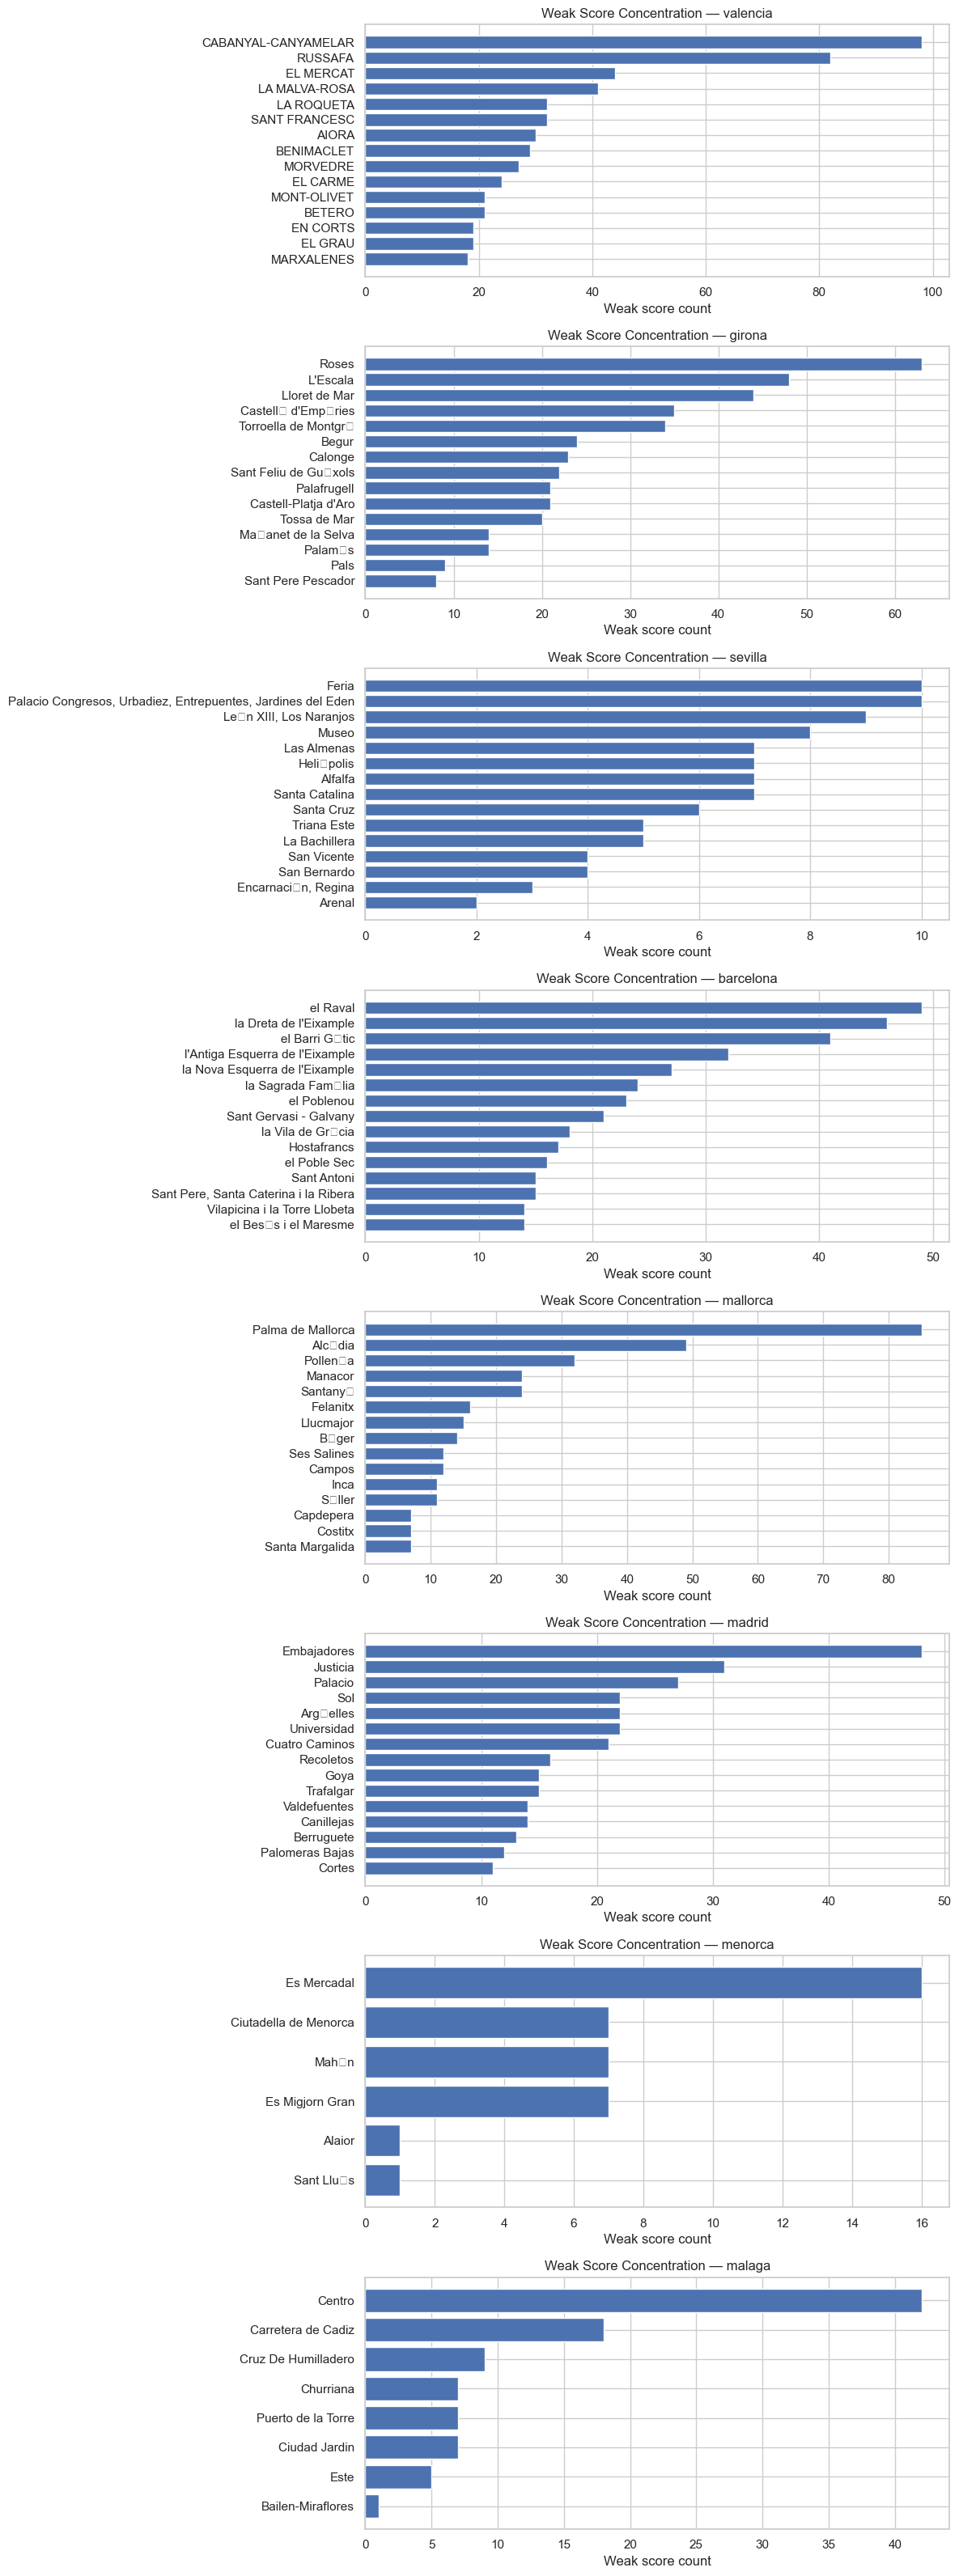

In [52]:
# 3.9 Plot heatmap (matplotlib only)
    # City-split (small multiples)
import matplotlib.pyplot as plt

score_cols = [
    "weak_review_scores_value",
    "weak_review_scores_rating",
    "weak_review_scores_accuracy",
    "weak_review_scores_cleanliness",
    "weak_review_scores_checkin",
    "weak_review_scores_communication",
    "weak_review_scores_location"
]

cities = df_stage3["city"].unique()

fig, axes = plt.subplots(
    nrows=len(cities),
    ncols=1,
    figsize=(12, 4 * len(cities))
)

if len(cities) == 1:
    axes = [axes]

for ax, city in zip(axes, cities):

    subset = (
        df_stage3[df_stage3["city"] == city]
        .groupby("neighbourhood_name")[score_cols]
        .sum()
    )

    # limit to top 15 neighbourhoods per city (IMPORTANT for readability)
    subset = subset.sum(axis=1).sort_values(ascending=False).head(15)
    subset = subset.to_frame("weak_total")

    ax.barh(subset.index[::-1], subset["weak_total"][::-1])
    ax.set_title(f"Weak Score Concentration — {city}")
    ax.set_xlabel("Weak score count")

plt.tight_layout()
plt.show()

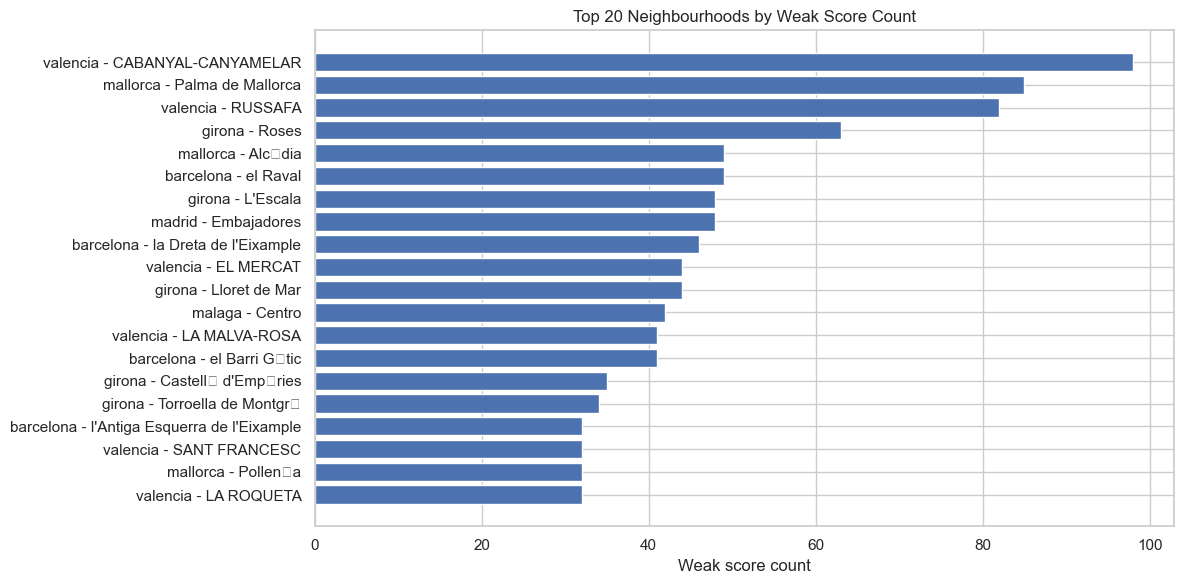

In [53]:
    # Ranked “problem score” per neighbourhood
top_neighbourhoods_plot = (
    df_stage3
    .groupby(["city", "neighbourhood_name"], dropna=False)
    .agg(
        weak_score_count=("weak_score_count", "sum"),
        total_listings=("apartment_id", "count"),
        avg_weak_score=("weak_score_count", "mean")
    )
    .reset_index()
    .sort_values("weak_score_count", ascending=False)
    .head(20)
)

top_neighbourhoods_plot["label"] = (
    top_neighbourhoods_plot["city"].astype(str)
    + " - " +
    top_neighbourhoods_plot["neighbourhood_name"].astype(str)
)

chart_df_neighbourhoods = top_neighbourhoods_plot[
    ["label", "weak_score_count"]
].copy()

plt.figure(figsize=(12, 6))

plt.barh(
    chart_df_neighbourhoods["label"][::-1],
    chart_df_neighbourhoods["weak_score_count"][::-1]
)

plt.title("Top 20 Neighbourhoods by Weak Score Count")
plt.xlabel("Weak score count")

plt.tight_layout()
plt.show()

In [85]:
df_stage3.groupby(["city", "neighbourhood_name"], dropna=False).agg(
        weak_score_count=("weak_score_count", "sum"),
        total_listings=("apartment_id", "count"),
        avg_weak_score=("weak_score_count", "mean")
    ).sort_values("weak_score_count")

weak_score_count  \
city      neighbourhood_name                                               
barcelona Diagonal Mar i el Front Mar�tim del Poblenou                 0   
          la Barceloneta                                               0   
girona    El Port de la Selva                                          0   
          Portbou                                                      0   
          Is�vol                                                       0   
...                                                                  ...   
mallorca  Alc�dia                                                     49   
girona    Roses                                                       63   
valencia  RUSSAFA                                                     82   
mallorca  Palma de Mallorca                                           85   
valencia  CABANYAL-CANYAMELAR                                         98   

                                                        total_listings  \
city      neighbourhood_name                                             
barcelona Diagonal Mar i el Front Mar�tim del Poblenou               1   
          la Barceloneta                                             2   
girona    El Port de la Selva                                        2   
          Portbou                                                    1   
          Is�vol                                                     1   
...                                                                ...   
mallorca  Alc�dia                                                    9   
girona    Roses                                                     16   
valencia  RUSSAFA                                                   23   
mallorca  Palma de Mallorca                                         24   
valencia  CABANYAL-CANYAMELAR                                       32   

                                                        avg_weak_score  
city      neighbourhood_name                                            
barcelona Diagonal Mar i el Front Mar�tim del Poblenou        0.000000  
          la Barceloneta                                      0.000000  
girona    El Port de la Selva                                 0.000000  
          Portbou                                             0.000000  
          Is�vol                                              0.000000  
...                                                                ...  
mallorca  Alc�dia                                             5.444444  
girona    Roses                                               3.937500  
valencia  RUSSAFA                                             3.565217  
mallorca  Palma de Mallorca                                   3.541667  
valencia  CABANYAL-CANYAMELAR                                 3.062500  

[280 rows x 3 columns]

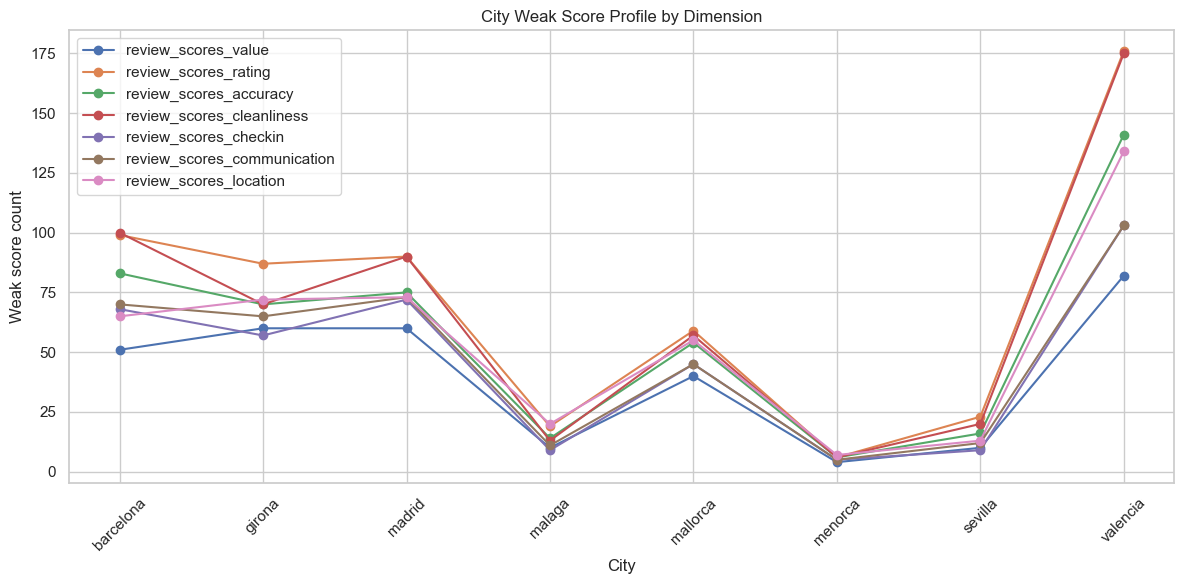

In [54]:
    # Issue-type breakdown per city
score_cols = [
    "weak_review_scores_value",
    "weak_review_scores_rating",
    "weak_review_scores_accuracy",
    "weak_review_scores_cleanliness",
    "weak_review_scores_checkin",
    "weak_review_scores_communication",
    "weak_review_scores_location"
]

city_issues = (
    df_stage3
    .groupby("city")[score_cols]
    .sum()
    .reset_index()
)

city_issues = city_issues.sort_values("city")

city_issues_records = city_issues.to_dict("records")

city_issues_norm = city_issues.copy()

city_issues_norm[score_cols] = (
    city_issues_norm[score_cols]
    .div(city_issues_norm[score_cols].sum(axis=1), axis=0)
)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for col in score_cols:
    plt.plot(
        city_issues["city"],
        city_issues[col],
        marker="o",
        label=col.replace("weak_", "")
    )

plt.title("City Weak Score Profile by Dimension")
plt.xlabel("City")
plt.ylabel("Weak score count")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



In [55]:
# 3.10 Identify dominant weak dimension per neighbourhood
heatmap_df["dominant_issue"] = heatmap_df[
    [
        "weak_value",
        "weak_rating",
        "weak_accuracy",
        "weak_cleanliness",
        "weak_checkin",
        "weak_communication",
        "weak_location"
    ]
].idxmax(axis=1)

In [56]:
# 3.11 City-level dominant issues
city_dominant_issue = (
    df_stage3
    .groupby("city")[weak_cols]
    .sum()
    .idxmax(axis=1)
    .reset_index()
)

city_dominant_issue.columns = ["city", "dominant_issue"]

city_dominant_issue

,city,dominant_issue
0,barcelona,weak_review_scores_cleanliness
1,girona,weak_review_scores_rating
2,madrid,weak_review_scores_rating
3,malaga,weak_review_scores_location
4,mallorca,weak_review_scores_rating
5,menorca,weak_review_scores_location
6,sevilla,weak_review_scores_rating
7,valencia,weak_review_scores_rating


##### Stage 4 — Statistical validation

In [57]:
# 4.1 Target variable

target = "review_scores_location"
df_stats = df_stage3.copy()

df_stats = df_stats.dropna(subset=[
    "city",
    "neighbourhood_name",
    target
])

In [58]:
# 4.2 Kruskal-Wallis per city
    #H: Does neighbourhood affect perceived location score inside each city?
results = []

for city in df_stats["city"].unique():

    city_data = df_stats[df_stats["city"] == city]

    groups = [
        group[target].values
        for _, group in city_data.groupby("neighbourhood_name")
        if len(group) >= 5  # stability condition
    ]

    if len(groups) < 2:
        continue

    stat, p_value = kruskal(*groups)

    n = len(city_data)
    k = len(groups)

    # Effect size approximation (eta squared for Kruskal-Wallis)
    eta_sq = (stat - k + 1) / (n - k)

    results.append({
        "city": city,
        "kw_stat": stat,
        "p_value": p_value,
        "effect_size_eta_sq": eta_sq,
        "n_observations": n,
        "n_neighbourhood_groups": k,
        "significant": p_value < 0.05
    })

df_kw = pd.DataFrame(results)

df_kw = df_kw.sort_values("effect_size_eta_sq", ascending=False)

df_kw

,city,kw_stat,p_value,effect_size_eta_sq,n_observations,n_neighbourhood_groups,significant
1,girona,8.062307,0.017754,0.074843,84,3,True
0,valencia,18.246194,0.108417,0.028010,236,13,False
3,mallorca,4.019622,0.134014,0.027666,76,3,False
4,madrid,4.272446,0.233508,0.010516,125,4,False
5,malaga,1.233968,0.266637,0.008356,30,2,False
2,barcelona,11.524507,0.484581,-0.003774,139,13,False


In [59]:
# 4.3 Interpretation rules
def interpret_effect(eta):

    if eta < 0.01:
        return "Negligible neighbourhood influence"
    elif eta < 0.06:
        return "Low neighbourhood influence"
    elif eta < 0.14:
        return "Moderate neighbourhood influence"
    else:
        return "High neighbourhood influence"

In [60]:
df_kw["effect_interpretation"] = df_kw["effect_size_eta_sq"].apply(interpret_effect)
df_kw_final = df_kw.sort_values(
    ["significant", "effect_size_eta_sq"],
    ascending=[False, False]
)

df_kw_final

,city,kw_stat,p_value,effect_size_eta_sq,n_observations,n_neighbourhood_groups,significant,effect_interpretation
1,girona,8.062307,0.017754,0.074843,84,3,True,Moderate neighbourhood influence
0,valencia,18.246194,0.108417,0.028010,236,13,False,Low neighbourhood influence
3,mallorca,4.019622,0.134014,0.027666,76,3,False,Low neighbourhood influence
4,madrid,4.272446,0.233508,0.010516,125,4,False,Low neighbourhood influence
5,malaga,1.233968,0.266637,0.008356,30,2,False,Negligible neighbourhood influence
2,barcelona,11.524507,0.484581,-0.003774,139,13,False,Negligible neighbourhood influence


In [61]:
# 4.4 Key marketing insights generator

def city_insight(row):

    if row["significant"] and row["effect_size_eta_sq"] > 0.14:
        return (
            f"{row['city']}: strong neighbourhood effect → "
            "location quality is structurally driven by area. "
            "High ROI for geo-targeted optimization."
        )

    if row["significant"]:
        return (
            f"{row['city']}: moderate neighbourhood effect → "
            "selective neighbourhood targeting recommended."
        )

    return (
        f"{row['city']}: weak or no neighbourhood effect → "
        "quality variation is listing-specific, not location-driven."
    )

df_kw_final["marketing_insight"] = df_kw_final.apply(city_insight, axis=1)

df_kw_final[[
    "city",
    "kw_stat",
    "p_value",
    "effect_size_eta_sq",
    "effect_interpretation",
    "significant",
    "marketing_insight"
]]

,city,kw_stat,p_value,effect_size_eta_sq,effect_interpretation,significant,marketing_insight
1,girona,8.062307,0.017754,0.074843,Moderate neighbourhood influence,True,girona: moderate neighbourhood effect → select...
0,valencia,18.246194,0.108417,0.028010,Low neighbourhood influence,False,valencia: weak or no neighbourhood effect → qu...
3,mallorca,4.019622,0.134014,0.027666,Low neighbourhood influence,False,mallorca: weak or no neighbourhood effect → qu...
4,madrid,4.272446,0.233508,0.010516,Low neighbourhood influence,False,madrid: weak or no neighbourhood effect → qual...
5,malaga,1.233968,0.266637,0.008356,Negligible neighbourhood influence,False,malaga: weak or no neighbourhood effect → qual...
2,barcelona,11.524507,0.484581,-0.003774,Negligible neighbourhood influence,False,barcelona: weak or no neighbourhood effect → q...


##### Stage 5 — Marketing Optimization (prioritization + action ranking)

In [62]:
marketing_neigh = (
    df_stage3
    .groupby(["city", "neighbourhood_name"])
    .agg(
        total_listings=("apartment_id", "count"),
        weak_score_avg=("weak_score_count", "mean"),
        weak_score_sum=("weak_score_count", "sum"),
        reviews_avg=("number_of_reviews", "mean"),
        zero_reviews=("number_of_reviews", lambda x: (x == 0).sum()),
        critical_share=("weak_score_count", lambda x: (x >= 3).mean())
    )
    .reset_index()
)

marketing = marketing_neigh.copy()

marketing["weak_norm"] = (
    marketing["weak_score_avg"] / marketing["weak_score_avg"].max()
)

marketing["review_gap_norm"] = (
    1 - (marketing["reviews_avg"] / marketing["reviews_avg"].max())
)

marketing["zero_review_norm"] = (
    marketing["zero_reviews"] / marketing["total_listings"]
)

marketing["critical_norm"] = marketing["critical_share"]


kw_city_effect = df_kw_final[["city", "effect_size_eta_sq"]]

marketing = marketing.merge(kw_city_effect, on="city", how="left")


marketing["effect_norm"] = (
    marketing["effect_size_eta_sq"] /
    marketing["effect_size_eta_sq"].max()
)


marketing["optimization_score"] = (
    0.35 * marketing["weak_norm"] +
    0.25 * marketing["review_gap_norm"] +
    0.20 * marketing["critical_norm"] +
    0.20 * marketing["effect_norm"]
)

In [63]:
# 5.6 Rank neighbourhoods (PRIORITY LIST)
marketing_ranked = marketing.sort_values(
    "optimization_score",
    ascending=False
)

marketing_ranked.head(20)

,city,neighbourhood_name,total_listings,weak_score_avg,weak_score_sum,reviews_avg,zero_reviews,critical_share,weak_norm,review_gap_norm,zero_review_norm,critical_norm,effect_size_eta_sq,effect_norm,optimization_score
79,girona,Santa Cristina d'Aro,1,7.000000,7,0.000000,1,1.0,1.000000,1.000000,1.000000,1.0,0.074843,1.000000,1.000000
81,girona,Torroella de Fluvi�,1,7.000000,7,0.000000,1,1.0,1.000000,1.000000,1.000000,1.0,0.074843,1.000000,1.000000
64,girona,Ma�anet de la Selva,2,7.000000,14,0.000000,2,1.0,1.000000,1.000000,1.000000,1.0,0.074843,1.000000,1.000000
77,girona,Sant Miquel de Fluvi�,1,7.000000,7,0.000000,1,1.0,1.000000,1.000000,1.000000,1.0,0.074843,1.000000,1.000000
86,girona,Vidreres,1,7.000000,7,0.000000,1,1.0,1.000000,1.000000,1.000000,1.0,0.074843,1.000000,1.000000
68,girona,Palam�s,2,7.000000,14,0.500000,1,1.0,1.000000,0.998663,0.500000,1.0,0.074843,1.000000,0.999666
66,girona,Osor,1,7.000000,7,3.000000,0,1.0,1.000000,0.991979,0.000000,1.0,0.074843,1.000000,0.997995
50,girona,Castell� d'Emp�ries,6,5.833333,35,0.666667,4,1.0,0.833333,0.998217,0.666667,1.0,0.074843,1.000000,0.941221
83,girona,Tossa de Mar,4,5.000000,20,8.000000,1,1.0,0.714286,0.978610,0.250000,1.0,0.074843,1.000000,0.894652
72,girona,Rab�s,1,5.000000,5,37.000000,0,1.0,0.714286,0.901070,0.000000,1.0,0.074843,1.000000,0.875267


In [64]:
# 5.7 Top 10 “hotspots” for Marketing intervention

top10_hotspots = marketing_ranked.head(10)

top10_hotspots

,city,neighbourhood_name,total_listings,weak_score_avg,weak_score_sum,reviews_avg,zero_reviews,critical_share,weak_norm,review_gap_norm,zero_review_norm,critical_norm,effect_size_eta_sq,effect_norm,optimization_score
79,girona,Santa Cristina d'Aro,1,7.000000,7,0.000000,1,1.0,1.000000,1.000000,1.000000,1.0,0.074843,1.0,1.000000
81,girona,Torroella de Fluvi�,1,7.000000,7,0.000000,1,1.0,1.000000,1.000000,1.000000,1.0,0.074843,1.0,1.000000
64,girona,Ma�anet de la Selva,2,7.000000,14,0.000000,2,1.0,1.000000,1.000000,1.000000,1.0,0.074843,1.0,1.000000
77,girona,Sant Miquel de Fluvi�,1,7.000000,7,0.000000,1,1.0,1.000000,1.000000,1.000000,1.0,0.074843,1.0,1.000000
86,girona,Vidreres,1,7.000000,7,0.000000,1,1.0,1.000000,1.000000,1.000000,1.0,0.074843,1.0,1.000000
68,girona,Palam�s,2,7.000000,14,0.500000,1,1.0,1.000000,0.998663,0.500000,1.0,0.074843,1.0,0.999666
66,girona,Osor,1,7.000000,7,3.000000,0,1.0,1.000000,0.991979,0.000000,1.0,0.074843,1.0,0.997995
50,girona,Castell� d'Emp�ries,6,5.833333,35,0.666667,4,1.0,0.833333,0.998217,0.666667,1.0,0.074843,1.0,0.941221
83,girona,Tossa de Mar,4,5.000000,20,8.000000,1,1.0,0.714286,0.978610,0.250000,1.0,0.074843,1.0,0.894652
72,girona,Rab�s,1,5.000000,5,37.000000,0,1.0,0.714286,0.901070,0.000000,1.0,0.074843,1.0,0.875267


In [65]:
# 5.8 City-level aggregation (strategic view)
city_strategy = (
    marketing_ranked
    .groupby("city")
    .agg(
        avg_optimization_score=("optimization_score", "mean"),
        total_listings=("total_listings", "sum"),
        avg_weak_score=("weak_score_avg", "mean"),
        avg_review_gap=("review_gap_norm", "mean")
    )
    .reset_index()
    .sort_values("avg_optimization_score", ascending=False)
)

city_strategy

,city,avg_optimization_score,total_listings,avg_weak_score,avg_review_gap
1,girona,0.702501,132,3.199844,0.961471
3,malaga,0.577883,36,4.106250,0.940965
7,valencia,0.577210,288,3.366932,0.912478
4,mallorca,0.546344,108,2.902382,0.955353
2,madrid,0.539492,165,3.424432,0.945768
0,barcelona,0.503466,176,3.599116,0.877689
5,menorca,NaN,13,3.736111,0.972185
6,sevilla,NaN,46,2.745652,0.853342


In [66]:
# 5.9 Marketing segmentation logic

def classify_city(score):

    if score > 0.65:
        return "HIGH PRIORITY (Aggressive intervention)"
    elif score > 0.45:
        return "MEDIUM PRIORITY (Targeted campaigns)"
    else:
        return "LOW PRIORITY (Monitoring)"
    
city_strategy["marketing_priority"] = city_strategy["avg_optimization_score"].apply(classify_city)

city_strategy[[
    "city",
    "avg_optimization_score",
    "avg_weak_score",
    "avg_review_gap",
    "marketing_priority"
]]

,city,avg_optimization_score,avg_weak_score,avg_review_gap,marketing_priority
1,girona,0.702501,3.199844,0.961471,HIGH PRIORITY (Aggressive intervention)
3,malaga,0.577883,4.106250,0.940965,MEDIUM PRIORITY (Targeted campaigns)
7,valencia,0.577210,3.366932,0.912478,MEDIUM PRIORITY (Targeted campaigns)
4,mallorca,0.546344,2.902382,0.955353,MEDIUM PRIORITY (Targeted campaigns)
2,madrid,0.539492,3.424432,0.945768,MEDIUM PRIORITY (Targeted campaigns)
0,barcelona,0.503466,3.599116,0.877689,MEDIUM PRIORITY (Targeted campaigns)
5,menorca,NaN,3.736111,0.972185,LOW PRIORITY (Monitoring)
6,sevilla,NaN,2.745652,0.853342,LOW PRIORITY (Monitoring)


##### Stage 6 — Geo-Clustering & Marketing Archetypes (unsupervised segmentation)

In [67]:
#6.1 Feature set for clustering
from sklearn.preprocessing import MinMaxScaler
features = marketing_neigh[[
    "weak_score_avg",
    "reviews_avg",
    "zero_reviews",
    "critical_share"
]].fillna(0)
scaler = MinMaxScaler()

# 6.2 Normalize features
features_norm = pd.DataFrame(
    scaler.fit_transform(features),
    columns=features.columns
)

n_clusters = 4

# 6.3 KMeans clustering
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

marketing_neigh["cluster"] = kmeans.fit_predict(features_norm)

# 6.4 Cluster profiling

cluster_profile = (
    marketing_neigh
    .groupby("cluster")[[
        "weak_score_avg",
        "reviews_avg",
        "zero_reviews",
        "critical_share"
    ]]
    .mean()
    .reset_index()
)

cluster_profile

# 6.5 Cluster interpretation (marketing archetypes)
def label_cluster(row):

    if row["weak_score_avg"] > 0.7 and row["reviews_avg"] < 0.3:
        return "🚨 Low visibility + quality issues"

    if row["weak_score_avg"] > 0.7:
        return "⚠️ Quality degradation cluster"

    if row["reviews_avg"] < 0.3:
        return "📉 Low demand / visibility cluster"

    if row["critical_share"] > 0.5:
        return "🔥 High-risk operational cluster"

    return "✅ Stable / mature market"


cluster_profile["label"] = cluster_profile.apply(label_cluster, axis=1)

# 6.6 Merge labels back to neighbourhoods

marketing_neigh = marketing_neigh.merge(
    cluster_profile[["cluster", "label"]],
    on="cluster",
    how="left"
)

# 6.7 Top clusters by strategic importance
cluster_priority = (
    marketing_neigh
    .groupby(["cluster", "label"])
    .agg(
        avg_weak=("weak_score_avg", "mean"),
        avg_reviews=("reviews_avg", "mean"),
        avg_critical=("critical_share", "mean"),
        total=("total_listings", "sum")
    )
    .reset_index()
    .sort_values("avg_weak", ascending=False)
)

cluster_priority

,cluster,label,avg_weak,avg_reviews,avg_critical,total
1,1,⚠️ Quality degradation cluster,5.868627,17.004902,0.997059,120
2,2,⚠️ Quality degradation cluster,4.431287,15.006618,0.666868,237
3,3,⚠️ Quality degradation cluster,2.858044,33.036085,0.445344,478
0,0,✅ Stable / mature market,0.682278,39.567722,0.011392,129


In [68]:
# 6.8 City × cluster distribution
city_cluster_map = (
    marketing_neigh
    .groupby(["city", "cluster"])
    .size()
    .reset_index(name="count")
)

city_cluster_map

,city,cluster,count
0,barcelona,0,9
1,barcelona,1,15
2,barcelona,2,3
3,barcelona,3,17
4,girona,0,16
5,girona,1,14
6,girona,2,9
7,girona,3,5
8,madrid,0,18
9,madrid,1,23


In [69]:
# 6.9 Final Marketing segmentation table

final_segments = marketing_neigh[[
    "city",
    "neighbourhood_name",
    "cluster",
    "label",
    "weak_score_avg",
    "reviews_avg",
    "critical_share",
    "total_listings"
]].sort_values("cluster")

final_segments

,city,neighbourhood_name,cluster,label,weak_score_avg,reviews_avg,critical_share,total_listings
0,barcelona,Can Bar�,0,✅ Stable / mature market,1.000000,374.000000,0.000000,1
1,barcelona,Diagonal Mar i el Front Mar�tim del Poblenou,0,✅ Stable / mature market,0.000000,118.000000,0.000000,1
2,barcelona,Horta,0,✅ Stable / mature market,1.000000,10.000000,0.000000,1
28,barcelona,la Barceloneta,0,✅ Stable / mature market,0.000000,6.500000,0.000000,2
31,barcelona,la Font de la Guatlla,0,✅ Stable / mature market,1.000000,200.000000,0.000000,2
...,...,...,...,...,...,...,...,...
25,barcelona,el Raval,3,⚠️ Quality degradation cluster,2.722222,44.000000,0.444444,18
23,barcelona,el Poblenou,3,⚠️ Quality degradation cluster,3.833333,20.833333,0.666667,6
22,barcelona,el Poble Sec,3,⚠️ Quality degradation cluster,2.000000,48.375000,0.250000,8
5,barcelona,Sant Antoni,3,⚠️ Quality degradation cluster,1.875000,44.125000,0.250000,8


##### Stage 6.2 — Cluster Validation + PCA Market Map (robustness check)

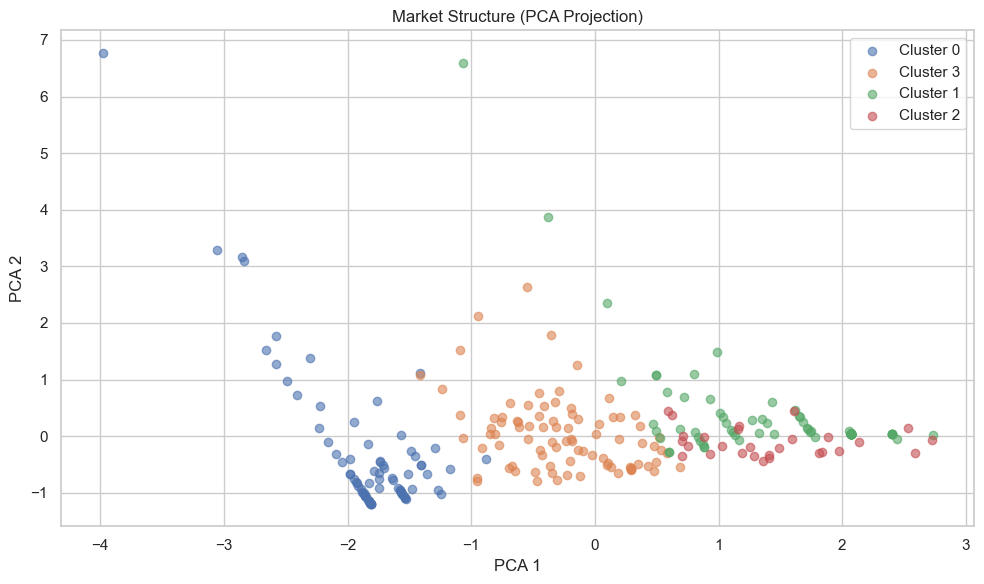

In [70]:

features = marketing_neigh[
    [
        "weak_score_avg",
        "reviews_avg",
        "zero_reviews",
        "critical_share"
    ]
].fillna(0)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(features_scaled)

marketing_neigh["pca_1"] = pca_components[:, 0]
marketing_neigh["pca_2"] = pca_components[:, 1]


import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for c in marketing_neigh["cluster"].unique():
    subset = marketing_neigh[marketing_neigh["cluster"] == c]

    plt.scatter(
        subset["pca_1"],
        subset["pca_2"],
        label=f"Cluster {c}",
        alpha=0.6
    )

plt.title("Market Structure (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()

plt.tight_layout()
plt.show()

In [71]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(features_scaled, marketing_neigh["cluster"])

sil_score

0.36059808284014194

In [72]:
cluster_quality = (
    marketing_neigh
    .groupby("cluster")
    .agg(
        size=("cluster", "count"),
        avg_weak=("weak_score_avg", "mean"),
        avg_reviews=("reviews_avg", "mean"),
        avg_critical=("critical_share", "mean")
    )
    .reset_index()
)

cluster_quality

,cluster,size,avg_weak,avg_reviews,avg_critical
0,0,79,0.682278,39.567722,0.011392
1,1,85,5.868627,17.004902,0.997059
2,2,28,4.431287,15.006618,0.666868
3,3,88,2.858044,33.036085,0.445344


In [73]:
from sklearn.metrics import pairwise_distances

centroids = marketing_neigh.groupby("cluster")[["pca_1", "pca_2"]].mean()

dist_matrix = pairwise_distances(centroids)

dist_matrix

array([[0.        , 3.42304303, 3.26017549, 1.62656434],
       [3.42304303, 0.        , 0.42676478, 1.79724322],
       [3.26017549, 0.42676478, 0.        , 1.66523051],
       [1.62656434, 1.79724322, 1.66523051, 0.        ]])

___